# Value-based Methods

Balancing **immediate** and **long-term goals** is challenging. We experience this tension every day: should I watch movies tonight, or keep studying reinforcement learning? The first choice gives us **immediate satisfaction**. The second may not give us much satisfaction tonight, but maybe (and only maybe) it will provide much **greater satisfaction in the long run**. But how much greater? We do not know, and we cannot know without trying it, without exploring. Life does not give us its MDP! We do not know exactly how our actions will affect the future, and even the same action may lead to different outcomes. This brings together the two fundamental challenges we have studied so far. We must **balance information gathering and information utilization**, while at the same time **reasoning about the long-term consequences** of our actions rather than only their immediate effects. In other words, we must deal simultaneously with exploration versus exploitation and immediate versus long-term reward.

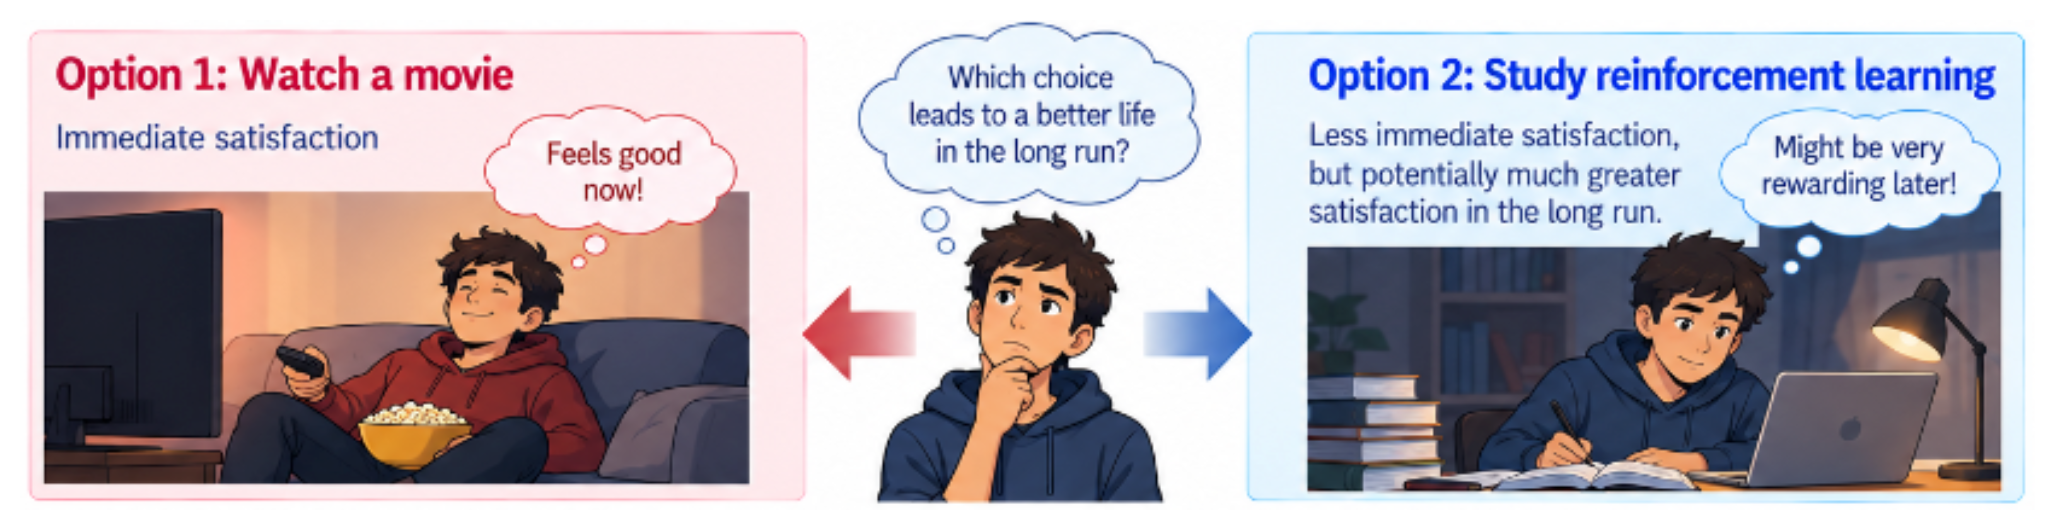

We will now study agents that can learn to estimate the value of policies, much like the policy-evaluation methods we encountered in dynamic programming, but with one crucial difference: this time, the agent does not know the MDP. **It must learn values from experience**. Before doing so, let us revisit three closely related but fundamentally different concepts:

- The **reward** is the one-step feedback signal received from the environment. The agent observes a state, selects an action, and receives a reward. Rewards tell us what is good immediately, but maximizing the reward received at each individual step is not the objective of reinforcement learning. A greedy pursuit of immediate reward can sacrifice much larger rewards available later.
- The **return** is the accumulated discounted reward from a given time onward. Unlike a single reward, it captures the long-term consequences of a sequence of decisions. However, in a stochastic environment, the return itself is a random variable. The same policy, starting from the same state, may produce a very high return in one episode and a very low return in another. Therefore, optimizing for one particular realized return is not enough.
- The **value function** captures what we really need: the expected return. It tells us how much discounted reward we can expect to accumulate in the future, on average, when following a particular policy. Random transitions and stochastic policies are therefore naturally accounted for: individual trajectories may differ, but their expected return defines the value.

The central idea is therefore simple: the agent is not trying to maximize the immediate reward, nor a single realized return. It is trying to find behavior that maximizes the **expected return** and **value functions allow us to reason about exactly that quantity**.

## Policy Evaluation


We begin with the simplest question: suppose the policy is fixed, how good is it? Answering this question means estimating its value function from sampled experience, without knowing the environment model. This is the **prediction problem**: learning the expected return obtained by following a given policy.

### Random Walk Environment

Consider a single-row grid-world with five non-terminal states and two terminal states. At each step, the agent can select either the left or right action. However, the environment is constructed so that both actions have exactly the same effect: regardless of the action selected, the agent moves left with probability 0.5 and right with probability 0.5. 

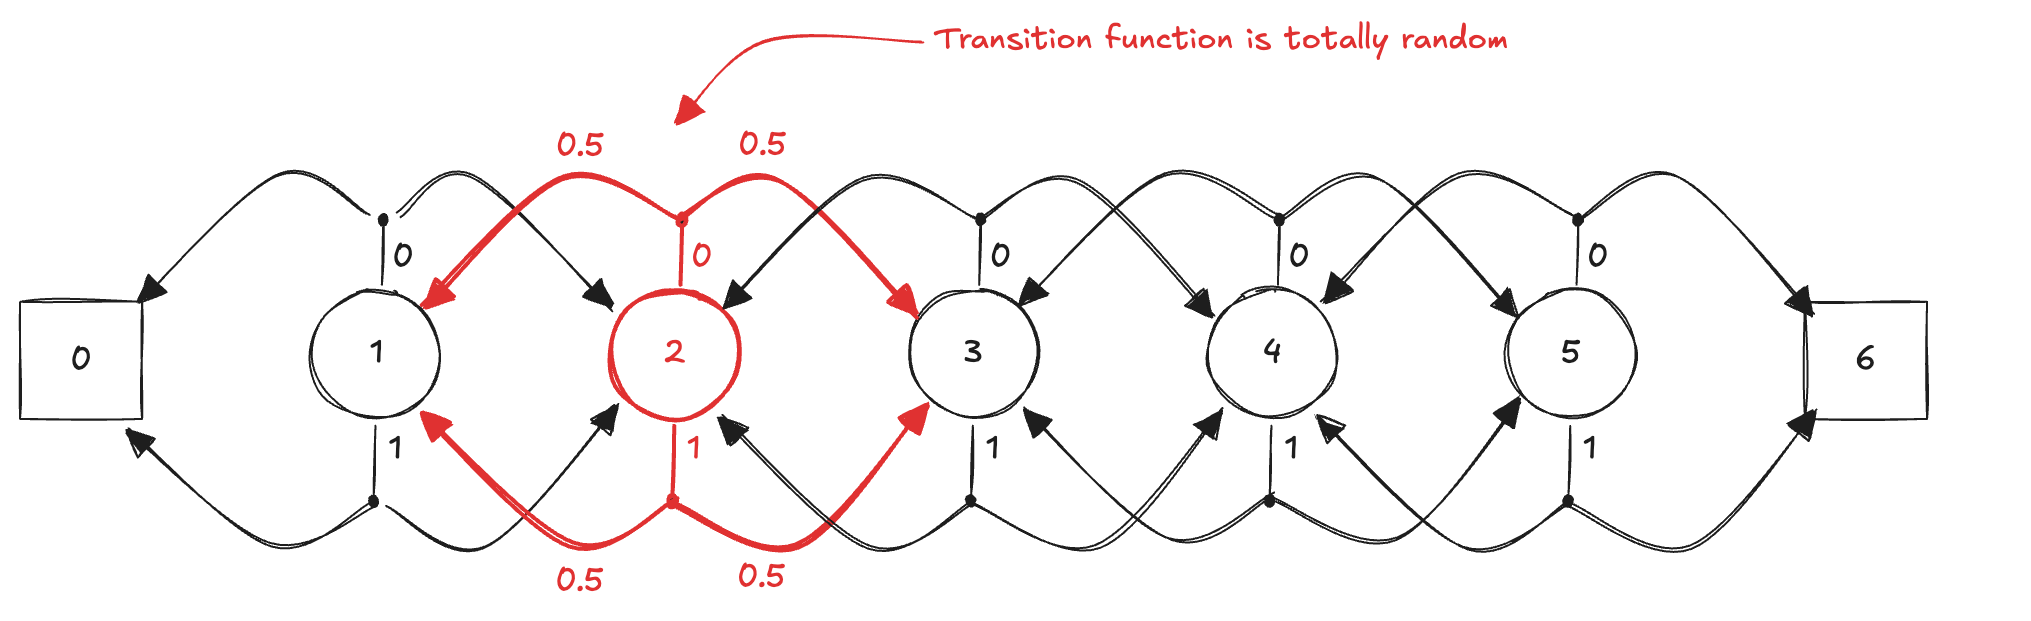

Therefore, the agent has **no actual control** over where it goes. Different actions do not induce different transition probabilities, so changing the policy cannot change the agent’s behavior or improve its performance.This apparently artificial property is precisely what makes the environment useful for studying policy evaluation. Since there is no meaningful control problem, we can **focus entirely on the prediction problem**: learning the value of each state from sampled experience. In particular, there is no need to disentangle the stochasticity introduced by the policy from that introduced by the environment dynamics. All uncertainty about the next state comes from the environment, allowing us to concentrate on the central question: **How can an agent learn the expected return from each state using only experience?**

In [2]:
import numpy as np

# Seven-state random-walk environment.
class RandomWalk:

    # State index:  [ 0    1    2    3    4    5    6 ]
    # State label:  [ T    A    B    C    D    E    T ]
    # Initial state:[ .    .    .    C    .    .    . ]

    observation_space = 7

    # True values for the equiprobable random walk
    v_true = np.array([0.0, 1/6, 2/6, 3/6, 4/6, 5/6, 0.0])

    def __init__(self):
        self.state = None
        self.terminated = False
        self.reset()

    def reset(self):
        self.state = np.random.choice([1, 2, 3, 4, 5])
        self.terminated = False
        return self.state

    def step(self, action):
        # The action is intentionally ignored:
        # left and right transitions are equiprobable.
        self.state += np.random.choice([-1, 1])

        reward = 0

        if self.state == 0:
            self.terminated = True

        elif self.state == 6:
            self.terminated = True
            reward = 1

        return self.state, reward, self.terminated, False, {}

random_walk = RandomWalk()

Because the environment dynamics make the policy being evaluated irrelevant, we can choose any policy. For simplicity, we use an all-left policy:

In [3]:
def pi(state):
    return 1

### Improving Estimates after Each Episode: Monte Carlo

Our goal is to estimate the state-value function of a fixed policy, that is, the expected return obtained when starting from state s and then following the policy:

$\displaystyle v_{\pi}(s) = \mathbb{E}_{\pi}[G_{t:T} \mid S_t=s]$

A natural way to estimate an expectation is through **sampling and averaging**. We run the policy for many episodes, collect trajectories, and average the returns observed after visiting each state.

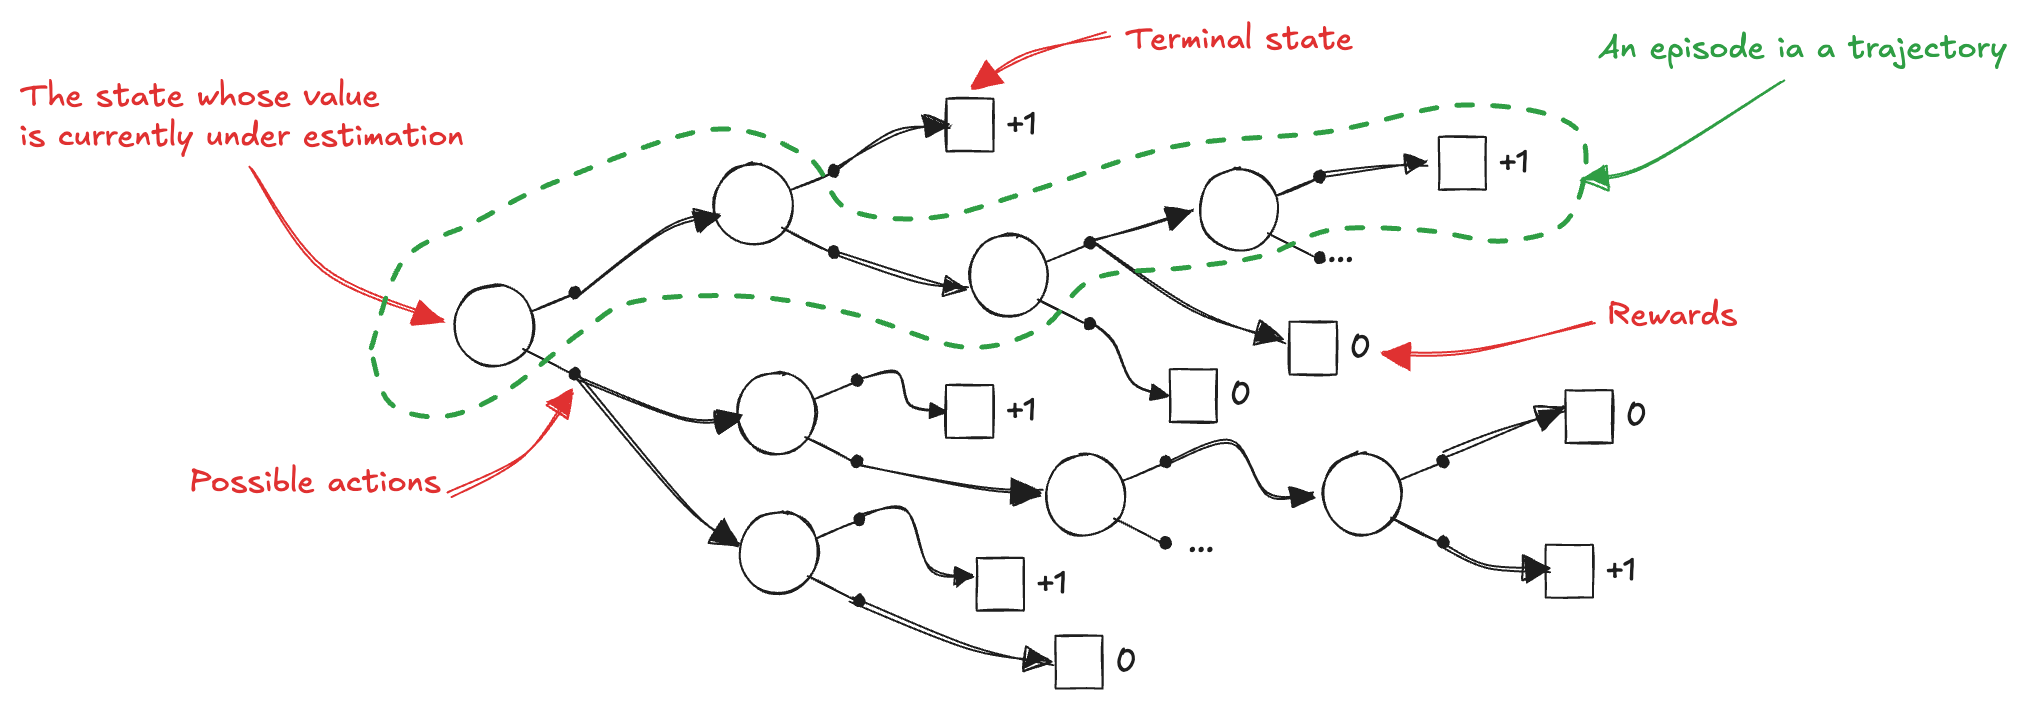

We first need a function that generates one complete trajectory by interacting with the environment according to the policy:

In [4]:
def generate_trajectory(pi, env, max_steps=200):

    # Store all experiences collected during the episode
    trajectory = []

    # Start a new episode and obtain the initial state
    state = env.reset()

    # Interact with the environment until termination
    # or until the maximum number of steps is reached
    for _ in range(max_steps):

        # Select an action according to the policy being evaluated
        action = pi(state)

        # Apply the action and observe the environment's response
        next_state, reward, terminated, truncated, info = env.step(action)

        # The episode ends either by reaching a terminal state
        # or because the environment truncates it
        done = terminated or truncated

        # Store the complete experience generated at this time step
        trajectory.append((state, action, reward, next_state, done))

        # Stop collecting experiences when the episode ends
        if done:
            break

        # Move to the next state and continue the episode
        state = next_state

    # Return the complete trajectory as a NumPy object array
    return np.array(trajectory, dtype=object)

This is the basic idea behind **Monte Carlo prediction (MC)**: estimate state values directly from **complete returns observed through experience**. Consider an episode generated by following the policy:

$\displaystyle S_t,A_t,R_{t+1},S_{t+1}$

$\displaystyle S_{t+1},A_{t+1},R_{t+2},S_{t+2}$

$\displaystyle \ldots$

$\displaystyle S_{T-1},A_{T-1},R_T,S_T$

Each state visit provides a different return, obtained by accumulating all subsequent discounted rewards until termination:

$\displaystyle G_{t:T}=R_{t+1}+\gamma R_{t+2}+\gamma^2R_{t+3}+\cdots+\gamma^{T-t-1}R_T$

$\displaystyle G_{t+1:T}=R_{t+2}+\gamma R_{t+3}+\gamma^2R_{t+4}+\cdots+\gamma^{T-t-2}R_T$

$\displaystyle \vdots$

$\displaystyle G_{T-1:T}=R_T$

Thus, a single episode provides **one return sample for each state visit**:

$\displaystyle S_t\rightarrow G_{t:T},\qquad S_{t+1}\rightarrow G_{t+1:T},\qquad\ldots$

Computing each return independently would be wasteful. Consecutive returns satisfy the recursion:

$\displaystyle \boxed{G_{t:T}=R_{t+1}+\gamma G_{t+1:T} \qquad G_{T:T}=0}$

Therefore, a **single backward pass** through the rewards computes all returns:

In [5]:
def compute_returns(rewards, gamma):

    # Convert the reward sequence to a NumPy array of floats
    rewards = np.asarray(rewards, dtype=float)

    # Allocate one return for each time step in the trajectory
    returns = np.zeros(len(rewards), dtype=float)

    # At the end of the episode, there are no future rewards
    G = 0.0

    # Process the trajectory backwards, from the last reward to the first

    for t in reversed(range(len(rewards))):

        # Compute the return recursively:
        # G_t = R_{t+1} + gamma * G_{t+1}
        G = rewards[t] + gamma * G

        # Store the return associated with the state visited at time t
        returns[t] = G

    # Return the complete sequence of Monte Carlo returns
    return returns

The discount factor controls how strongly distant rewards contribute to the return: a reward received k steps into the future is weighted by $\gamma^k$. With $\gamma=1$, all rewards contribute equally, decreasing $\gamma$ progressively reduces the influence of distant rewards:

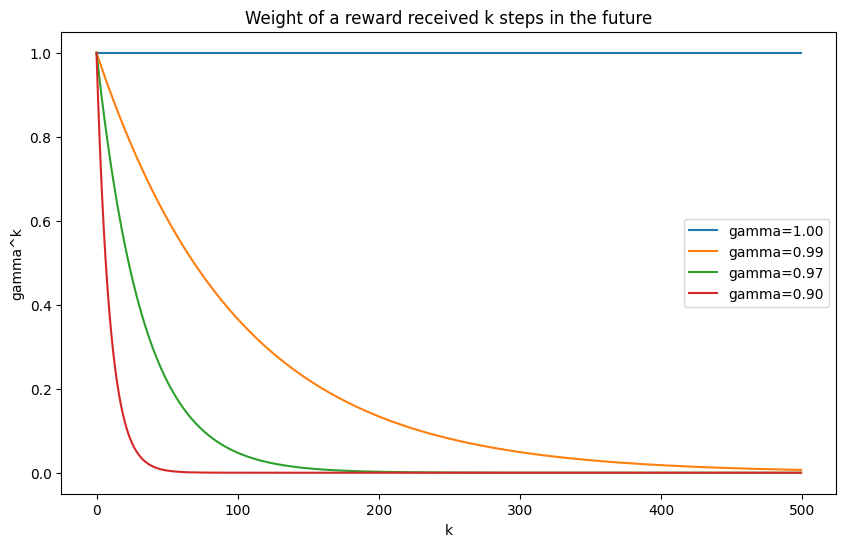

In [6]:
import matplotlib.pyplot as plt

# Number of steps into the future
k = np.arange(500)

# Plot the weight of future rewards for different discount factors
plt.figure(figsize=(10, 6))

plt.plot(1.00 ** k, label='gamma=1.00')
plt.plot(0.99 ** k, label='gamma=0.99')
plt.plot(0.97 ** k, label='gamma=0.97')
plt.plot(0.90 ** k, label='gamma=0.90')

# Add labels and legend
plt.title('Weight of a reward received k steps in the future')
plt.xlabel('k')
plt.ylabel('gamma^k')
plt.legend()

plt.show()

Now suppose that at time i we visit state $S_i=s$. The corresponding return $G_{i:T}$ is one sample of the return from state s. After many visits to s, we obtain:

$\displaystyle G^{(1)}(s),G^{(2)}(s),\ldots,G^{(N(s))}(s)$

Monte Carlo prediction estimates the expected return by taking their empirical mean:

$\displaystyle \boxed{V(s)=\frac{1}{N(s)}\sum_{j=1}^{N(s)}G^{(j)}(s)}$

As the number of samples increases, this estimate approaches the true state value:

$\displaystyle N(s)\rightarrow\infty\quad\Rightarrow\quad V(s)\rightarrow v_\pi(s)$

This is the fundamental idea behind Monte Carlo prediction: **experience complete returns and average them to estimate their expectation**. We do not need to store all previous returns. The same sample mean can be updated incrementally whenever a new return becomes available:

$\displaystyle V(S_i)\leftarrow V(S_i)+\frac{1}{N(S_i)}\left[G_{i:T}-V(S_i)\right]$

More generally, we can replace $1/N(S_i)$ with a learning rate $\alpha$:

$\displaystyle \boxed{V(S_i)\leftarrow V(S_i)+\alpha\underbrace{\left[\underbrace{G_{i:T}}_{\text{MC target}}-V(S_i)\right]}_{\text{MC error}}}$

$\displaystyle \boxed{V(S_i)\leftarrow V(S_i)+\alpha\left[G_{i:T}-V(S_i)\right]}$
 
The update therefore follows the familiar pattern:

**new estimate = old estimate + step size $\times$ error**

Notice that **MC target** contains **only rewards actually experienced** by the agent. It uses neither a model of the environment nor an estimate of future value. The price is that the complete return is known only after the episode terminates, so **Monte Carlo methods can update their estimates only after observing the final outcome**.

This is the same incremental estimator introduced for the multi-armed bandit problem, now applied to states rather than actions. Choosing $\alpha=1/N(S_i)$ reproduces the sample average, while a constant $\alpha$ produces a recency-weighted estimate. In our experiments, we use the same constant $\alpha$ for all prediction methods, so differences in their behavior are due to how they construct their targets rather than to different step-size schedules.

### First-visit and Every-visit Monte Carlo


There is one detail we must clarify before turning Monte Carlo prediction into an algorithm. **A single trajectory may visit the same state more than once**. Suppose, for example, that an episode contains:

$\displaystyle S_0=A,\quad S_1=B,\quad S_2=A,\quad S_3=C,\quad S_4=D,\ldots$

State A is visited twice, and the two visits generally produce different returns:

$\displaystyle G_{0:T}\neq G_{2:T}$

Should both returns be used to update V(A)?

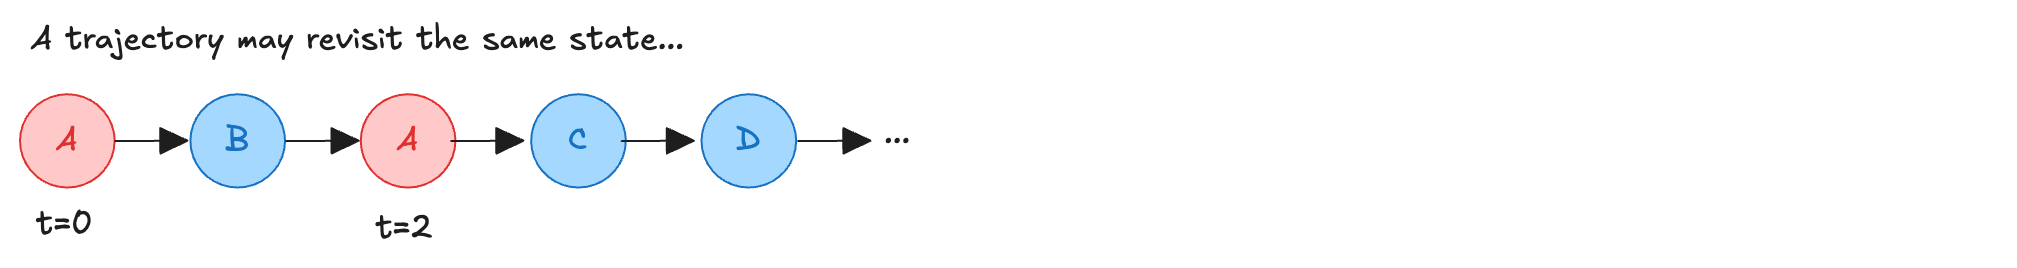

In f**irst-visit Monte Carlo (FVMC)**, only the return following the **first occurrence** of each state in an episode is used. In this example, A contributes only $G_{0:T}$. Therefore, each state contributes at most one target per episode:

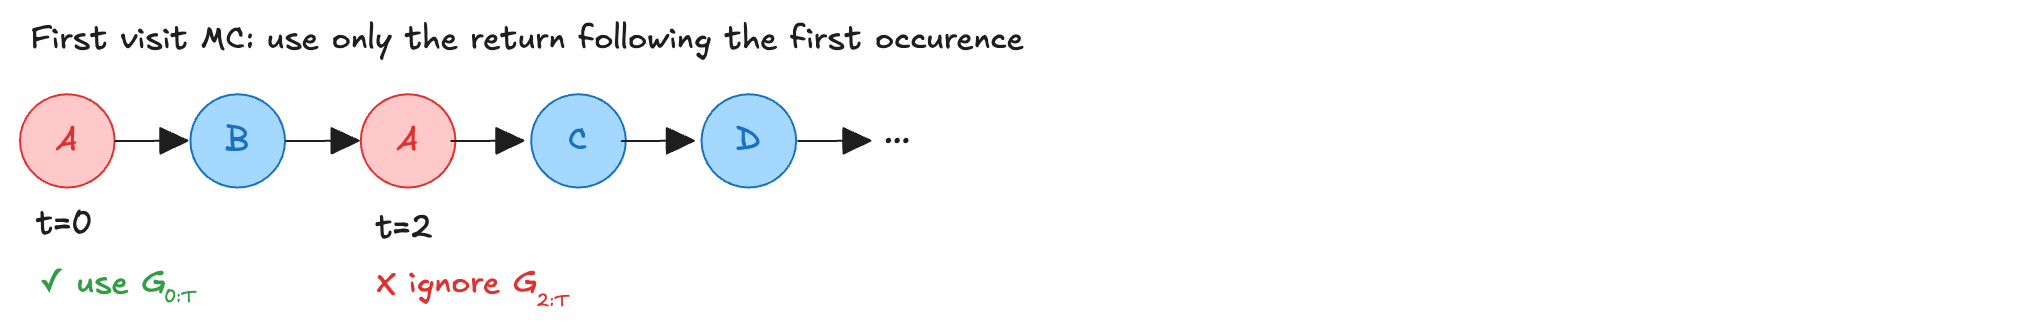

In **every-visit Monte Carlo (EVMC)**, instead, the return following **every occurrence** of a state is used. Therefore, both $G_{0:T}$ and $G_{2:T}$ contribute to the estimate of V(A):

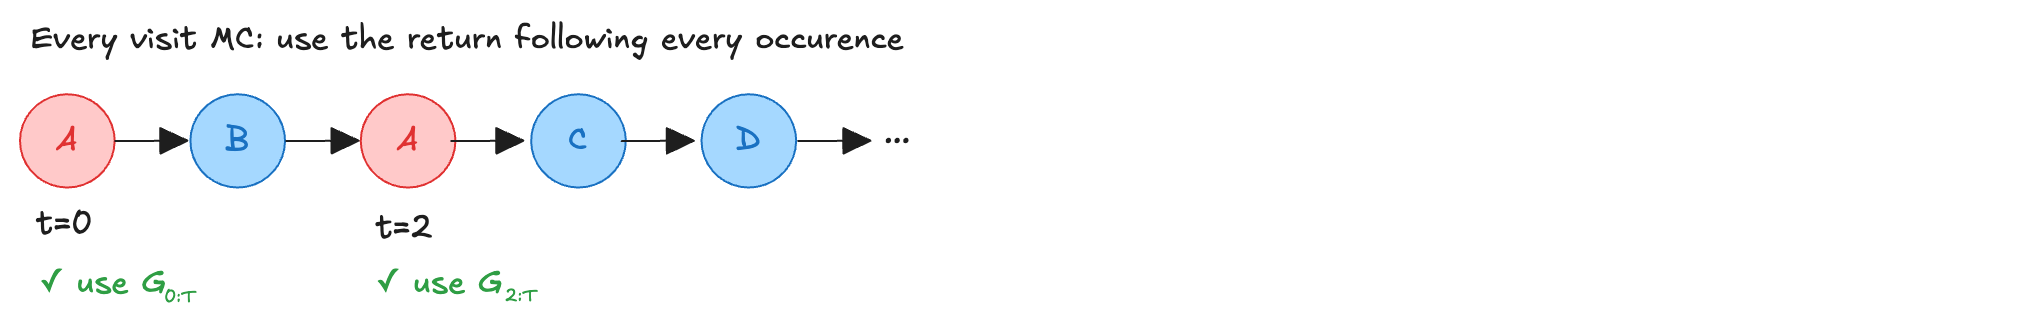

Both approaches are valid and converge under standard conditions. First-visit MC has a particularly direct convergence argument: returns following first visits to a state behave as independent samples with expectation $v_\pi(s)$, so their average converges to the true value by the law of large numbers. Every-visit MC also converges, although returns generated by repeated visits within the same episode are generally correlated.

We now implement first-visit Monte Carlo prediction:

In [7]:
def mc(pi, env, gamma=1.0, alpha=0.1, n_episodes=500, max_steps=200):

    # Initialize the current estimate of the state-value function
    v = np.zeros(env.observation_space, dtype=float)

    # Store the value estimates after each episode
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float)

    # Generate and process one complete trajectory per episode
    for e in range(n_episodes):

        # Generate an episode by following the policy
        trajectory = generate_trajectory(pi, env, max_steps)

        # Compute the return associated with every state visit
        # using a single backward pass through the rewards
        returns = compute_returns(trajectory[:, 2], gamma)

        # Track which states have already been processed in this episode
        visited = np.zeros(env.observation_space, dtype=bool)

        # Process the trajectory from beginning to end
        for t, (state, _, _, _, _) in enumerate(trajectory):

            # First-visit MC: ignore repeated visits to the same state
            if visited[state]:
                continue

            visited[state] = True

            # Monte Carlo target and error
            mc_target = returns[t]
            mc_error = mc_target - v[state]

            # Update the value estimate
            v[state] = v[state] + alpha * mc_error

        # Save the value function after the complete episode
        v_track[e] = v

    return v.copy(), v_track

We can now apply MC prediction to the Random Walk environment:

In [8]:
v_mc, v_mc_track = mc(pi, random_walk, n_episodes=500)

print('State   MC estimate   True value')
print('--------------------------------')
for s in range(1, 6):
    print(f'{s:^5}   {v_mc[s]:^11.3f}   {random_walk.v_true[s]:^10.3f}')

State   MC estimate   True value
--------------------------------
  1        0.087        0.167   
  2        0.242        0.333   
  3        0.484        0.500   
  4        0.612        0.667   
  5        0.756        0.833   


To understand how learning evolves, we can plot the estimates of the five non-terminal states across episodes:

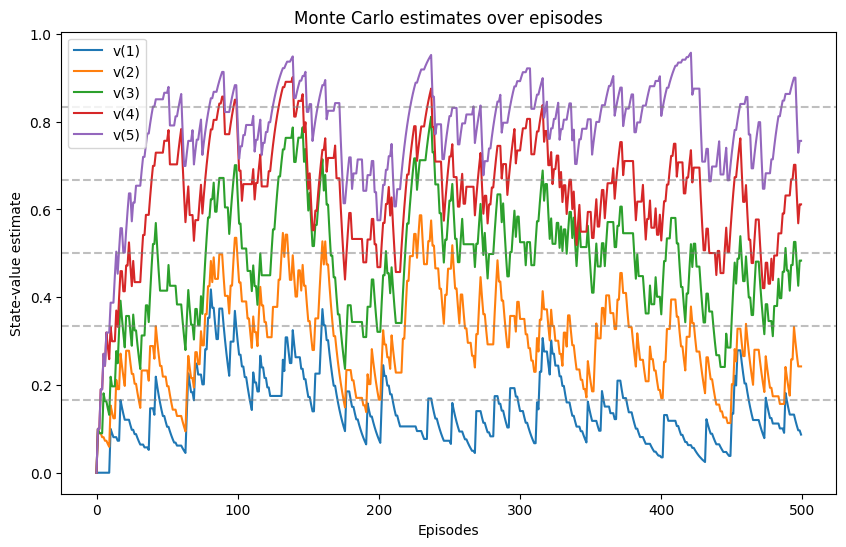

In [18]:
plt.figure(figsize=(10, 6))

# Plot the learned value estimates
plt.plot(v_mc_track[:, 1:6])

# Plot the true state values
plt.axhline(random_walk.v_true[1], color='gray', linestyle='--', alpha=0.5)
plt.axhline(random_walk.v_true[2], color='gray', linestyle='--', alpha=0.5)
plt.axhline(random_walk.v_true[3], color='gray', linestyle='--', alpha=0.5)
plt.axhline(random_walk.v_true[4], color='gray', linestyle='--', alpha=0.5)
plt.axhline(random_walk.v_true[5], color='gray', linestyle='--', alpha=0.5)

plt.title('Monte Carlo estimates over episodes')
plt.xlabel('Episodes')
plt.ylabel('State-value estimate')
plt.legend(['v(1)', 'v(2)', 'v(3)', 'v(4)', 'v(5)'])

plt.show()

The estimates gradually move toward the true state values. However, **the trajectories are quite noisy**: even after approaching the correct values, they **continue to fluctuate** from episode to episode. This is a characteristic property of Monte Carlo learning. **Each update is based on a complete sampled return, and complete returns can vary considerably across trajectories**. MC targets are **unbiased samples** of the expected return, but they can have **high variance**. To obtain a more reliable view of learning performance, we repeat the experiment many times and measure the root mean-squared error (RMSE) between the estimated and true value functions. For one run, the RMS error after an episode is:

$\displaystyle \operatorname{RMSE}=\sqrt{\frac{1}{|\mathcal{S}|}\sum_{s\in\mathcal{S}}\left(V(s)-v_\pi(s)\right)^2}$

We then average this quantity across multiple independent runs:

In [10]:
def run_experiment(algorithm, runs, env, pi):

    v_runs = []

    # Repeat the complete learning experiment several times
    for _ in range(runs):
        _, v_track = algorithm(pi, env)
        v_runs.append(v_track)

    v_runs = np.array(v_runs)

    # Remove the two terminal states
    v_runs = v_runs[:, :, 1:-1]

    # Compute the error with respect to the true value function
    error_to_true = v_runs - env.v_true[1:-1]

    # RMS error over the five non-terminal states
    squared_error = np.power(error_to_true, 2)
    mean_squared_error = np.mean(squared_error, axis=-1)
    root_mean_squared_error = np.sqrt(mean_squared_error)

    # Average the learning curve over all independent runs
    rmse_avg_over_runs = np.mean(root_mean_squared_error, axis=0)

    return rmse_avg_over_runs

We can now estimate the Monte Carlo learning curve over 100 independent runs:

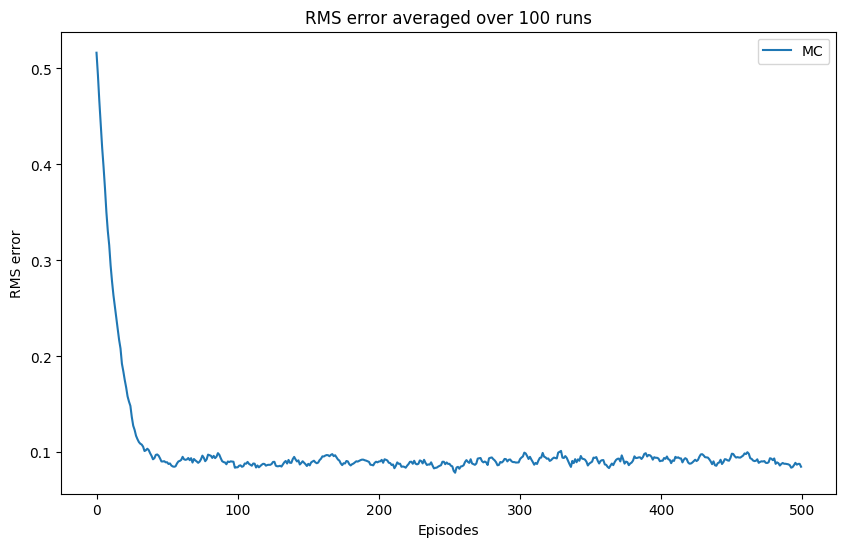

In [11]:
rmse_mc = run_experiment(mc, 100, random_walk, pi)

plt.figure(figsize=(10, 6))
plt.plot(rmse_mc, label='MC')
plt.title('RMS error averaged over 100 runs')
plt.xlabel('Episodes')
plt.ylabel('RMS error')
plt.legend()
plt.show()

The learning curve shows that the error decreases rapidly at the beginning, as the agent collects return samples and improves its initial estimates. Later, the improvement becomes slower and the curve settles around a small residual error. The remaining fluctuations are not surprising. Monte Carlo updates use complete returns sampled from entire trajectories, so two visits to the same state can generate substantially different targets depending on what happens later in the episode. This gives MC relatively high-variance updates. This observation motivates the next question: **do we really need to wait until the end of the episode and use the entire sampled return?** Temporal-difference learning will answer this by replacing part of the return with an existing value estimate.

### Improving estimates after each step: Temporal-Difference Learning

Monte Carlo prediction has an appealing property: its target is the actual return experienced by the agent. For a fixed policy, this return is an **unbiased sample** of the value we want to estimate. However, this comes with two important limitations. First, MC must **wait until the episode terminates**. The complete return:

$\displaystyle G_{t:T}=R_{t+1}+\gamma R_{t+2}+\cdots+\gamma^{T-t-1}R_T$

is not known until all subsequent rewards have been observed. Therefore, the agent cannot update the value function immediately after leaving a state. Second, **complete returns can have high variance**. From time t to termination, the trajectory may contain many stochastic transitions and rewards. All this randomness is accumulated into a single return $G_{t:T}$. Thus, although the MC target is unbiased, individual samples can differ substantially, producing noisy updates. Can we learn from a transition without waiting for the complete return?

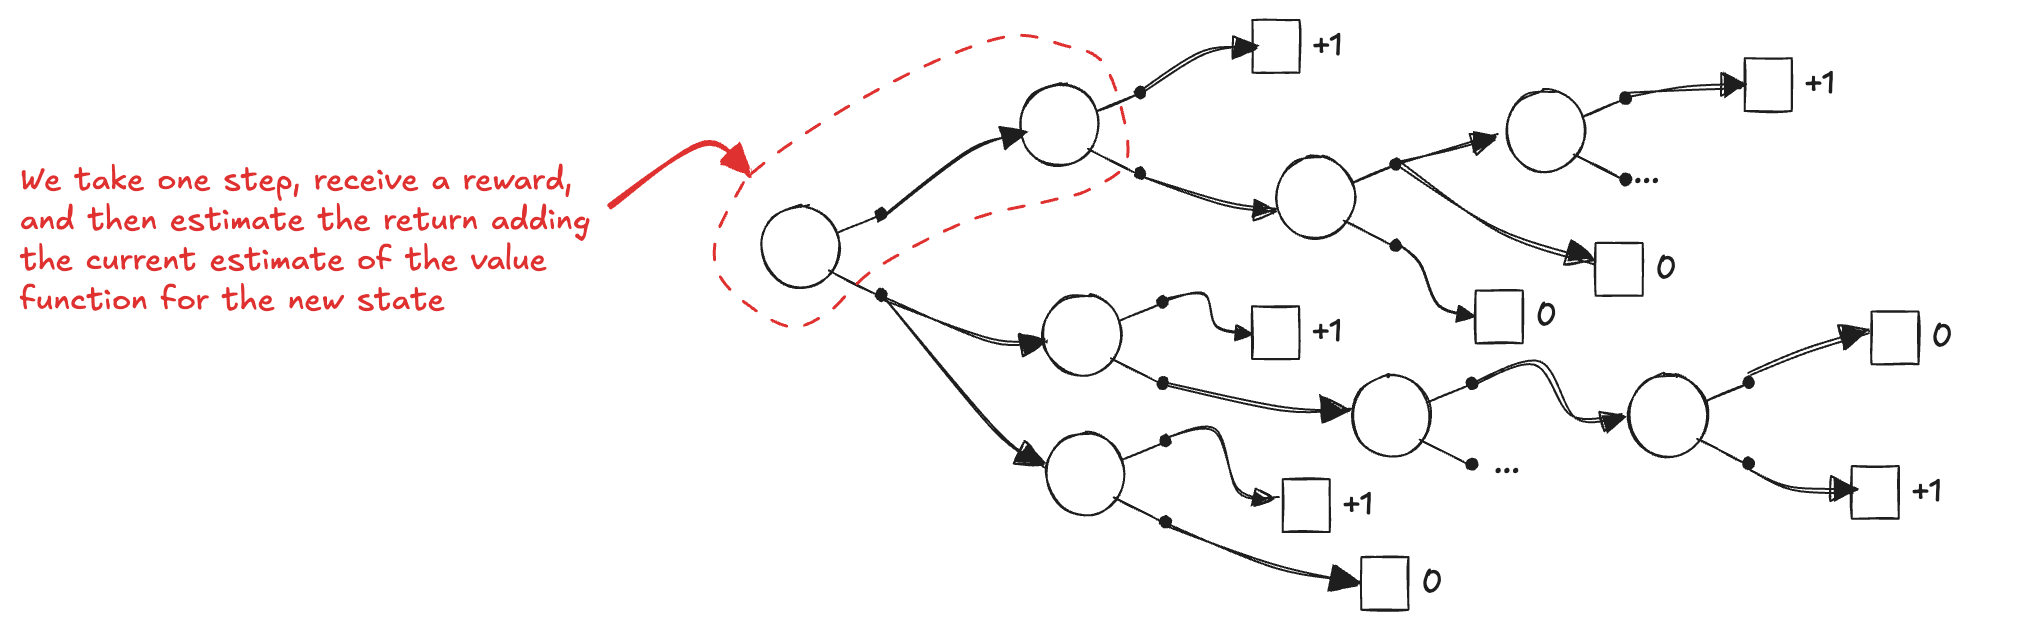

Recall the recursive relationship between consecutive returns:

$\displaystyle G_{t:T}=R_{t+1}+\gamma R_{t+2}+\gamma^2R_{t+3}+\cdots+\gamma^{T-t-1}R_T$

$\displaystyle =R_{t+1}+\gamma\left(R_{t+2}+\gamma R_{t+3}+\cdots+\gamma^{T-t-2}R_T\right)$

and therefore:

$\displaystyle G_{t:T}=R_{t+1}+\gamma G_{t+1:T}$

Monte Carlo waits until the end of the episode to observe $G_{t+1:T}$. But **we are already learning an estimate of its expectation**: $V(S_{t+1})$. Temporal-Difference learning makes the crucial substitution:

$\displaystyle G_{t+1:T}\,\longrightarrow\,V(S_{t+1})$

giving the **one-step TD target**:

$\displaystyle \boxed{G_{t:t+1}=R_{t+1}+\gamma V(S_{t+1})}$

Instead of waiting for the complete future, **TD uses one reward from experience and then its current estimate of the remaining return**.The value estimate can therefore be updated immediately after each transition:

$\displaystyle \boxed{V(S_t)\leftarrow V(S_t)+\alpha\underbrace{\left[\underbrace{R_{t+1}+\gamma V(S_{t+1})}_{\text{TD target}}-V(S_t)\right]}_{\text{TD error}}}$

This is the same learning structure we used for Monte Carlo:

**new estimate = old estimate + step size $\times$ error**

but the target has changed. MC uses the complete action return:

$\displaystyle G_{t:T}$

whereas TD(0) uses the one-step estimated return:

$\displaystyle R_{t+1} + \gamma V(S_{t+1})$

This idea of updating an estimate using another estimate is called **bootstrapping**:

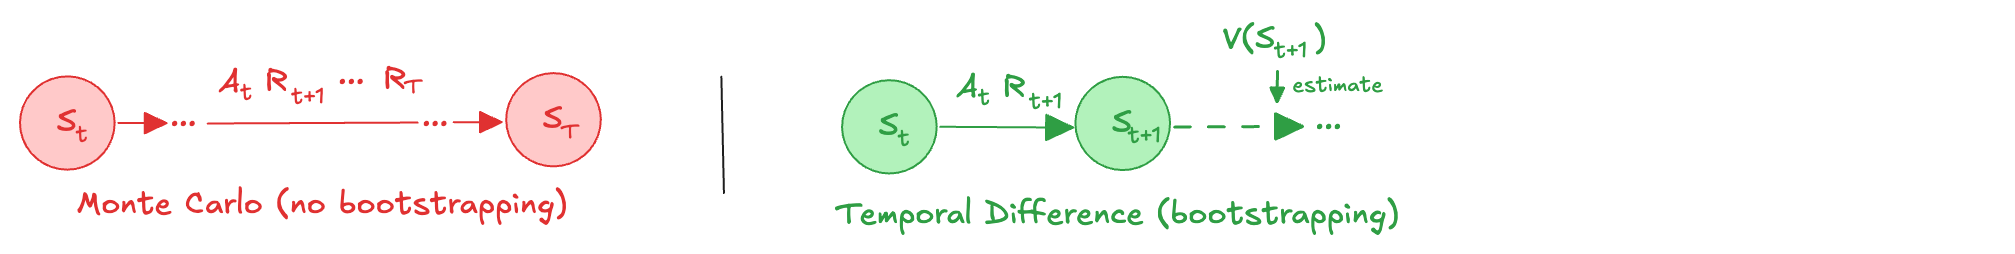

The observed reward $R_{t+1}$ **anchors the update in real experience**, while $V(S_{t+1})$ supplies an estimate of everything that may happen afterward. There is an important trade-off. The MC target contains the randomness accumulated over the entire remainder of the trajectory, giving it potentially high variance but no bootstrapping bias. The TD target depends only on the observed one-step transition before bootstrapping, so it typically **has lower variance**, but its target depends on the current, possibly inaccurate estimate $V(S_{t+1})$ and therefore **introduces bias**.This also explains why TD can be viewed as combining ideas from Monte Carlo and Dynamic Programming. Like MC, TD learns directly from sampled experience and requires no model of the environment. Like DP, TD bootstraps, updating one value estimate using another value estimate. The crucial difference from DP is that DP uses an expectation over all possible one-step transitions, whereas TD learns from the single transition actually sampled from the environment. We can implement one-step TD, usually called TD(0), directly:

In [1]:
def td(pi, env, gamma=1.0, alpha=0.1, n_episodes=500):

    # Initialize the state-value estimates
    v = np.zeros(env.observation_space, dtype=float)

    # Store the value estimates after each episode
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float)

    # Run one interaction sequence for each episode
    for e in range(n_episodes):

        # Start a new episode
        state = env.reset()
        done = False

        # TD learns after every transition
        while not done:

            # Select an action according to the policy
            action = pi(state)

            # Take one step in the environment
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            # Compute the one-step TD target and TD error
            td_target = reward + gamma * v[next_state] * (not done)
            td_error = td_target - v[state]

            # Immediately update the current state
            v[state] = v[state] + alpha * td_error

            # Continue from the next state
            state = next_state

        # Store the estimates at the end of the episode
        v_track[e] = v

    return v.copy(), v_track

Notice the fundamental difference from the MC implementation: there is **no trajectory to store** and **no return to compute** after termination. Each experience:

$\displaystyle (S_t,A_t,R_{t+1},S_{t+1})$

is sufficient to perform an update immediately. We can now apply TD(0) to the Random Walk environment:

In [12]:
v_td, v_td_track = td(pi, random_walk, n_episodes=500)

print('State   TD estimate   True value')
print('--------------------------------')
for s in range(1, 6):
    print(f'{s:^5}   {v_td[s]:^11.3f}   {random_walk.v_true[s]:^10.3f}')

State   TD estimate   True value
--------------------------------
  1        0.191        0.167   
  2        0.310        0.333   
  3        0.482        0.500   
  4        0.636        0.667   
  5        0.768        0.833   


and inspect how the estimates evolve:

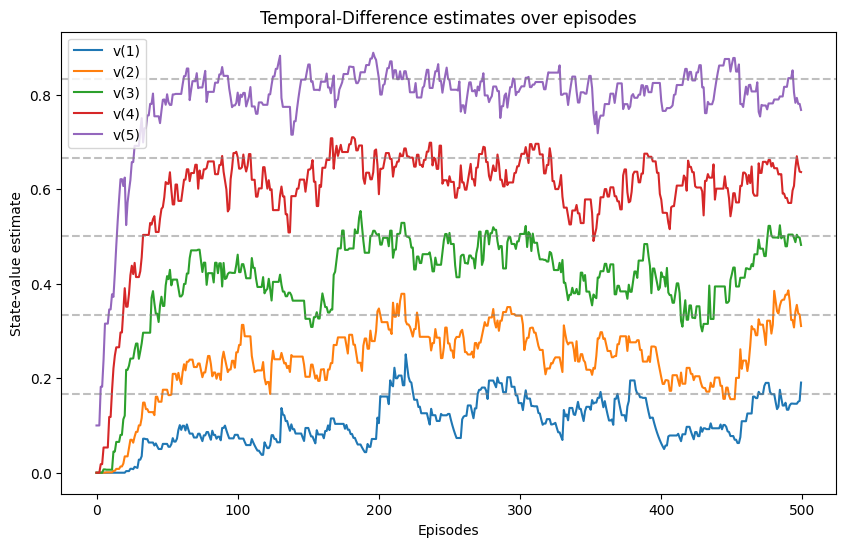

In [19]:
plt.figure(figsize=(10, 6))

# Plot the learned value estimates
plt.plot(v_td_track[:, 1:6])

# Plot the true state values
plt.axhline(random_walk.v_true[1], color='gray', linestyle='--', alpha=0.5)
plt.axhline(random_walk.v_true[2], color='gray', linestyle='--', alpha=0.5)
plt.axhline(random_walk.v_true[3], color='gray', linestyle='--', alpha=0.5)
plt.axhline(random_walk.v_true[4], color='gray', linestyle='--', alpha=0.5)
plt.axhline(random_walk.v_true[5], color='gray', linestyle='--', alpha=0.5)

plt.title('Temporal-Difference estimates over episodes')
plt.xlabel('Episodes')
plt.ylabel('State-value estimate')
plt.legend(['v(1)', 'v(2)', 'v(3)', 'v(4)', 'v(5)'])

plt.show()

Compared with MC using the same constant step size, the TD estimates typically **fluctuate less** because each target contains much less sampled randomness. However, **early in learning they can be systematically inaccurate** because TD bootstraps from value estimates that are themselves still inaccurate. This is the characteristic **bias–variance trade-off** between the two methods. To compare them more reliably, we average the RMS error over many independent runs:

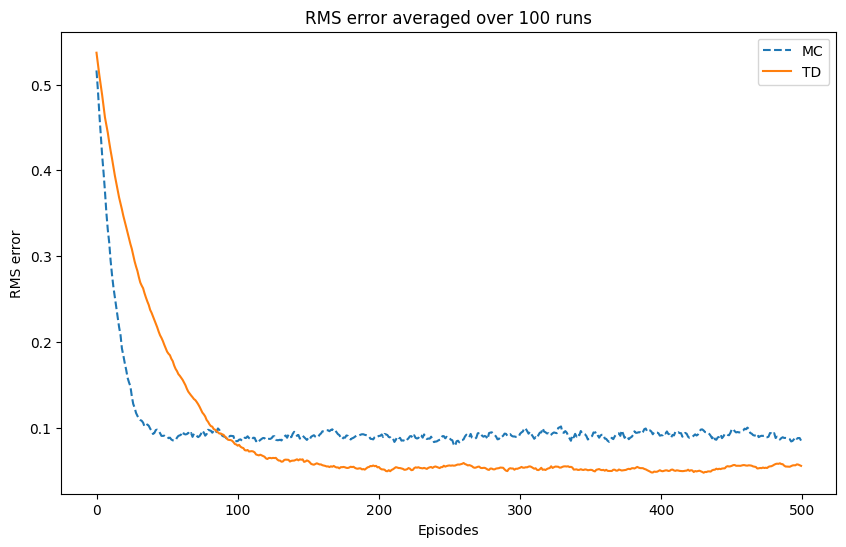

In [14]:
rmse_td = run_experiment(td, 100, random_walk, pi)

plt.figure(figsize=(10, 6))

plt.plot(rmse_mc, linestyle='--', label='MC')
plt.plot(rmse_td, label='TD')

plt.title('RMS error averaged over 100 runs')
plt.xlabel('Episodes')
plt.ylabel('RMS error')
plt.legend()
plt.show()

For this Random Walk problem and these hyperparameters, TD reduces the RMS error faster than MC and maintains a lower average error over much of the learning process. The reason is not that TD is universally superior to MC. Rather, in this experiment, its lower-variance one-step targets compensate effectively for the bias introduced by bootstrapping. 

The natural next question is whether we can choose **something between these two extremes**, using several real rewards before bootstrapping. That leads directly to n-step Temporal-Difference learning.

### Improving estimates after multiple steps: n-steps TD

Monte Carlo and TD(0) represent two extremes in how we construct a target. Monte Carlo waits until the end of the episode, using all the rewards actually experienced before updating. TD(0) waits only one step, using one observed reward and then bootstrapping from the current value estimate. But is there something in between?

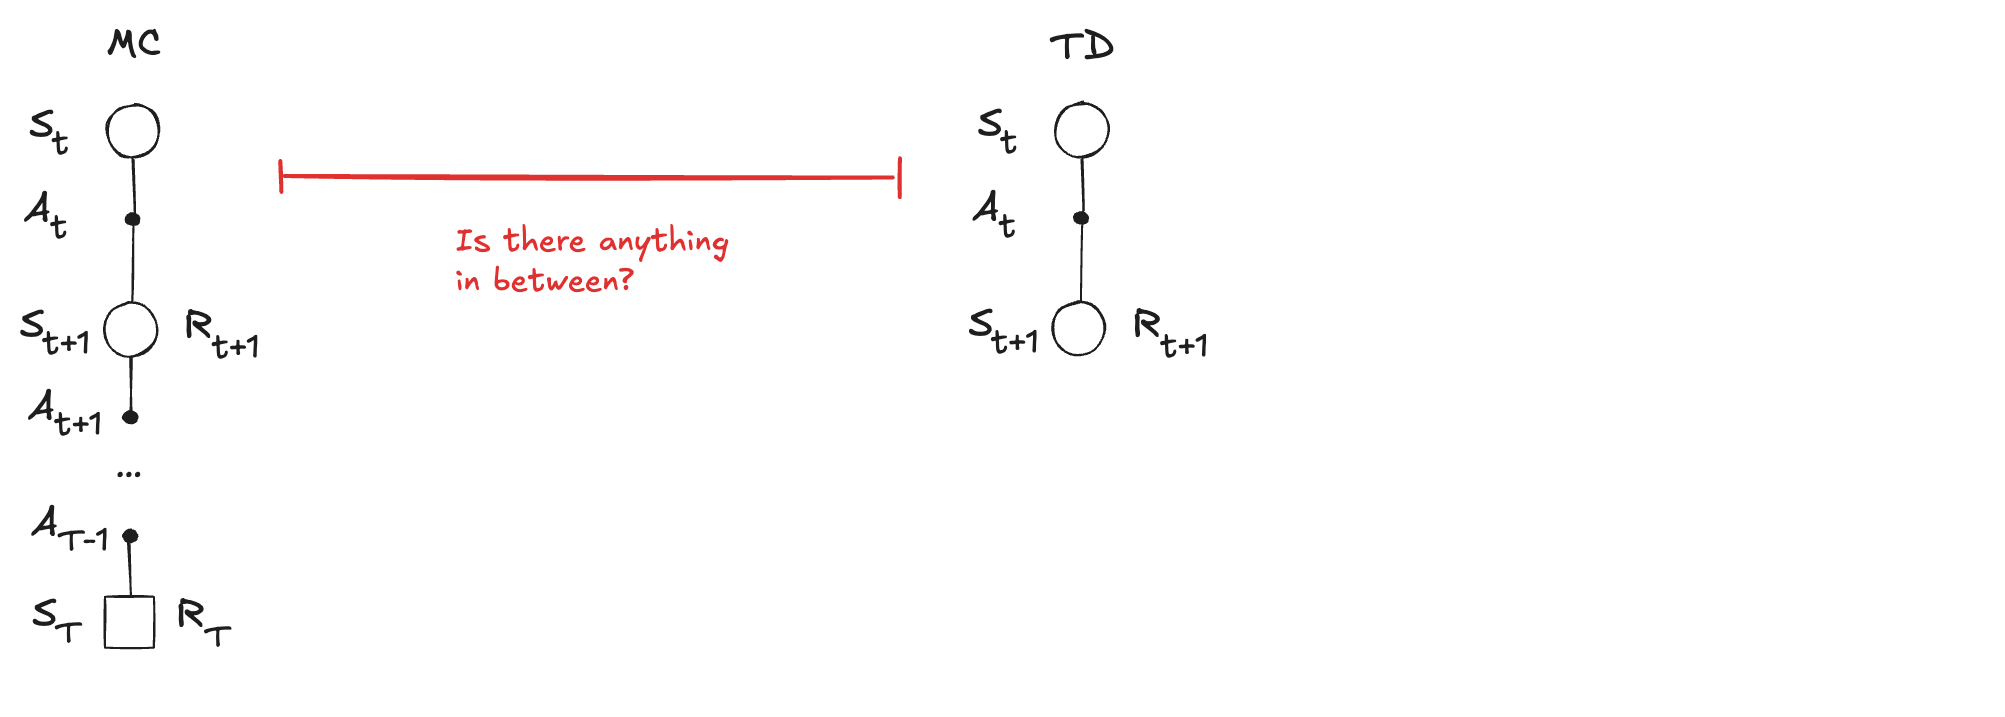

Instead of bootstrapping after one step, we could wait for two steps, three steps, or, more generally, n steps. This gives us a family of methods forming a spectrum between TD(0) and Monte Carlo. This family is called **n-step Temporal-Difference learning**. It allows us to control how many actual rewards we observe before bootstrapping, providing a way **to balance bootstrapping bias and sampling variance**. Starting from state $S_t$, we interact with the environment for up to n steps:

$\displaystyle S_t,A_t,R_{t+1},S_{t+1},\ldots,R_{t+n},S_{t+n}$

If the episode terminates before n transitions have been observed, we simply stop at the terminal state and use the rewards available up to termination. As with MC, we need a helper function to generate trajectory segments, but this time each segment contains at most n steps:

In [22]:
def generate_path(pi, env, state, n_steps):

    # Store the experiences collected along the path
    path = []

    done = False

    # Collect at most n transitions
    while len(path) < n_steps:

        # Select an action according to the policy
        action = pi(state)

        # Take one step in the environment
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Store the experience
        path.append((state, action, reward, next_state, done))

        # Stop early if the episode terminates
        if done:
            break

        # Continue from the next state
        state = next_state

    return np.array(path, dtype=object)

The three cases can now be compared directly. Monte Carlo uses the complete return:

$\displaystyle G_{t:T}=R_{t+1}+\gamma R_{t+2}+\cdots+\gamma^{T-t-1}R_T$     
$\displaystyle V(S_t)\leftarrow V(S_t)+\alpha\left[G_{t:T}-V(S_t)\right]$

One-step TD instead uses one actual reward and then bootstraps:

$\displaystyle G_{t:t+1}=R_{t+1}+\gamma V(S_{t+1})$     
$\displaystyle V(S_t)\leftarrow V(S_t)+\alpha\left[G_{t:t+1}-V(S_t)\right]$

The n-step method extends exactly the same idea. We observe n actual rewards and then bootstrap from the value of the state reached after those $n$ steps:

$\displaystyle \boxed{G_{t:t+n}=R_{t+1}+\gamma R_{t+2}+\cdots+\gamma^{n-1}R_{t+n}+\gamma^nV(S_{t+n})}$      

$\displaystyle \boxed{V(S_t)\leftarrow V(S_t)+\alpha\underbrace{\left[\underbrace{G_{t:t+n}}_{\text{n-step TD target}}-V(S_t)\right]}_{\text{n-step TD error}}}$

The interpretation is straightforward: the first n rewards come from actual experience, everything beyond $S_{t+n}$ is summarized by the current estimate $V(S_{t+n})$. As n increases, we use more real rewards and rely less on bootstrapping. At one extreme:

$\displaystyle n=1\quad\Rightarrow\quad G_{t:t+1}=R_{t+1}+\gamma V(S_{t+1})\quad\Rightarrow\quad\text{TD(0)}$

At the other extreme, if the episode terminates before the n-th step, there is no future value from which to bootstrap:

$\displaystyle t+n\geq T\quad\Rightarrow\quad G_{t:t+n}=G_{t:T}\quad\Rightarrow\quad\text{Monte Carlo}$

Thus, TD(0) and Monte Carlo are the two extremes of the same family of n-step methods.

In [20]:
def ntd(pi, env, gamma=1.0, n_steps=3, alpha=0.1, n_episodes=500):

    # Initialize the state-value estimates
    v = np.zeros(env.observation_space, dtype=float)

    # Store the estimates after each episode
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float)

    # Run one complete episode at a time
    for e in range(n_episodes):

        state = env.reset()
        done = False

        # Process the episode in paths of at most n steps
        while not done:

            # Generate the next path
            path = generate_path(pi, env, state, n_steps)

            # The path may be shorter than n if termination occurs
            n = len(path)

            # Compute the partial returns from the observed rewards
            partial_returns = compute_returns(path[:, 2], gamma)

            # Determine where to bootstrap
            bootstrap_state = path[n - 1, 3]
            path_done = path[n - 1, 4]

            # Update the states encountered along the path
            for t, (state, _, _, next_state, done) in enumerate(path):

                # Add the bootstrapped value after the observed rewards
                ntd_target = (
                    partial_returns[t]
                    + (gamma ** (n - t))
                    * v[bootstrap_state]
                    * (not path_done)
                )

                ntd_error = ntd_target - v[state]
                v[state] = v[state] + alpha * ntd_error

                state = next_state

        # Store the value function after the episode
        v_track[e] = v

    return v.copy(), v_track

We can apply the method to the Random Walk environment using 3-step TD:

In [23]:
v_ntd, v_ntd_track = ntd(
    pi,
    random_walk,
    n_steps=3,
    n_episodes=500
)

print('State   nTD estimate   True value')
print('---------------------------------')
for s in range(1, 6):
    print(f'{s:^5}   {v_ntd[s]:^12.3f}   {random_walk.v_true[s]:^10.3f}')

State   nTD estimate   True value
---------------------------------
  1        0.114         0.167   
  2        0.271         0.333   
  3        0.649         0.500   
  4        0.773         0.667   
  5        0.877         0.833   


We can also visualize how the estimates evolve during learning:

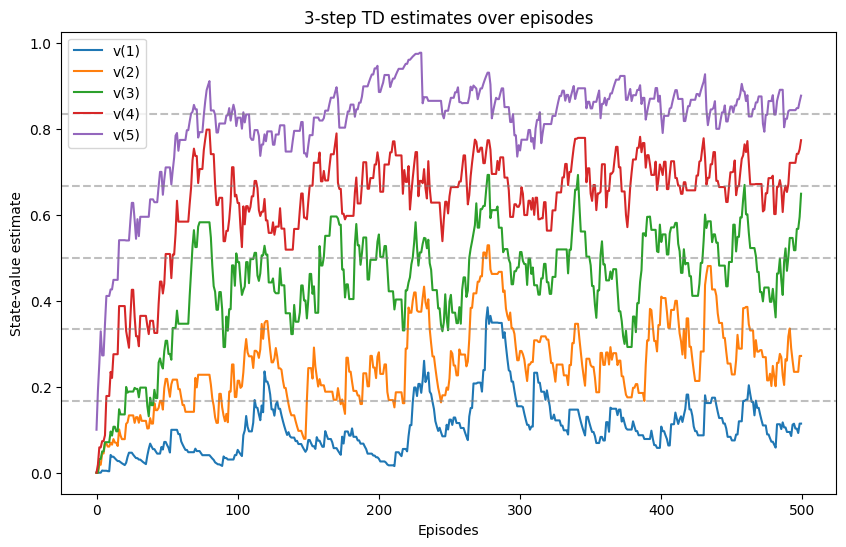

In [24]:
plt.figure(figsize=(10, 6))

plt.plot(v_ntd_track[:, 1:6])

# Plot the true state values
plt.axhline(random_walk.v_true[1], color='gray', linestyle='--', alpha=0.5)
plt.axhline(random_walk.v_true[2], color='gray', linestyle='--', alpha=0.5)
plt.axhline(random_walk.v_true[3], color='gray', linestyle='--', alpha=0.5)
plt.axhline(random_walk.v_true[4], color='gray', linestyle='--', alpha=0.5)
plt.axhline(random_walk.v_true[5], color='gray', linestyle='--', alpha=0.5)

plt.title('3-step TD estimates over episodes')
plt.xlabel('Episodes')
plt.ylabel('State-value estimate')
plt.legend(['v(1)', 'v(2)', 'v(3)', 'v(4)', 'v(5)'])

plt.show()

Finally, we compare MC, TD(0), and 3-step TD using the same step size:

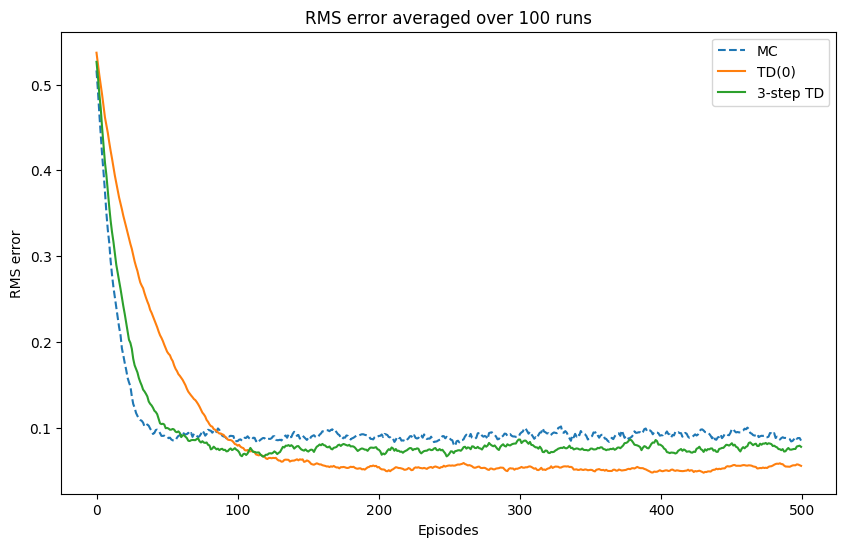

In [25]:
rmse_ntd = run_experiment(ntd, 100, random_walk, pi)

plt.figure(figsize=(10, 6))

plt.plot(rmse_mc, linestyle='--', label='MC')
plt.plot(rmse_td, label='TD(0)')
plt.plot(rmse_ntd, label='3-step TD')

plt.title('RMS error averaged over 100 runs')
plt.xlabel('Episodes')
plt.ylabel('RMS error')
plt.legend()
plt.show()

The parameter n determines **how far we rely on real experience before bootstrapping**. With a small n, the target contains few sampled rewards and relies heavily on the current value estimates. This generally gives lower variance but greater dependence on potentially inaccurate estimates. With a larger n, the target contains more actual rewards and relies less on bootstrapping, reducing this source of bias but accumulating more randomness from the trajectory. Thus, **n controls a bias–variance trade-off**:

$\displaystyle \text{small }n\,\longrightarrow\,\text{more bootstrapping, lower variance}$        
$\displaystyle \text{large }n\,\longrightarrow\,\text{less bootstrapping, higher variance}$

There is no universally optimal value of n. It depends on the environment, the reward structure, the step size, and the learning problem. In fact, intermediate values of n can perform better than both TD(0) and Monte Carlo, as shown in the classical Random Walk experiments. 

### Improving estimates of all visited states: TD($\lambda$)

The n-step TD introduces a new question: **what is a good value of n?** How many real rewards should we observe before bootstrapping? Instead of choosing a single n, we can take a different approach: **combine all the n-step targets into a single target**, giving more weight to shorter returns and progressively less weight to longer ones. 

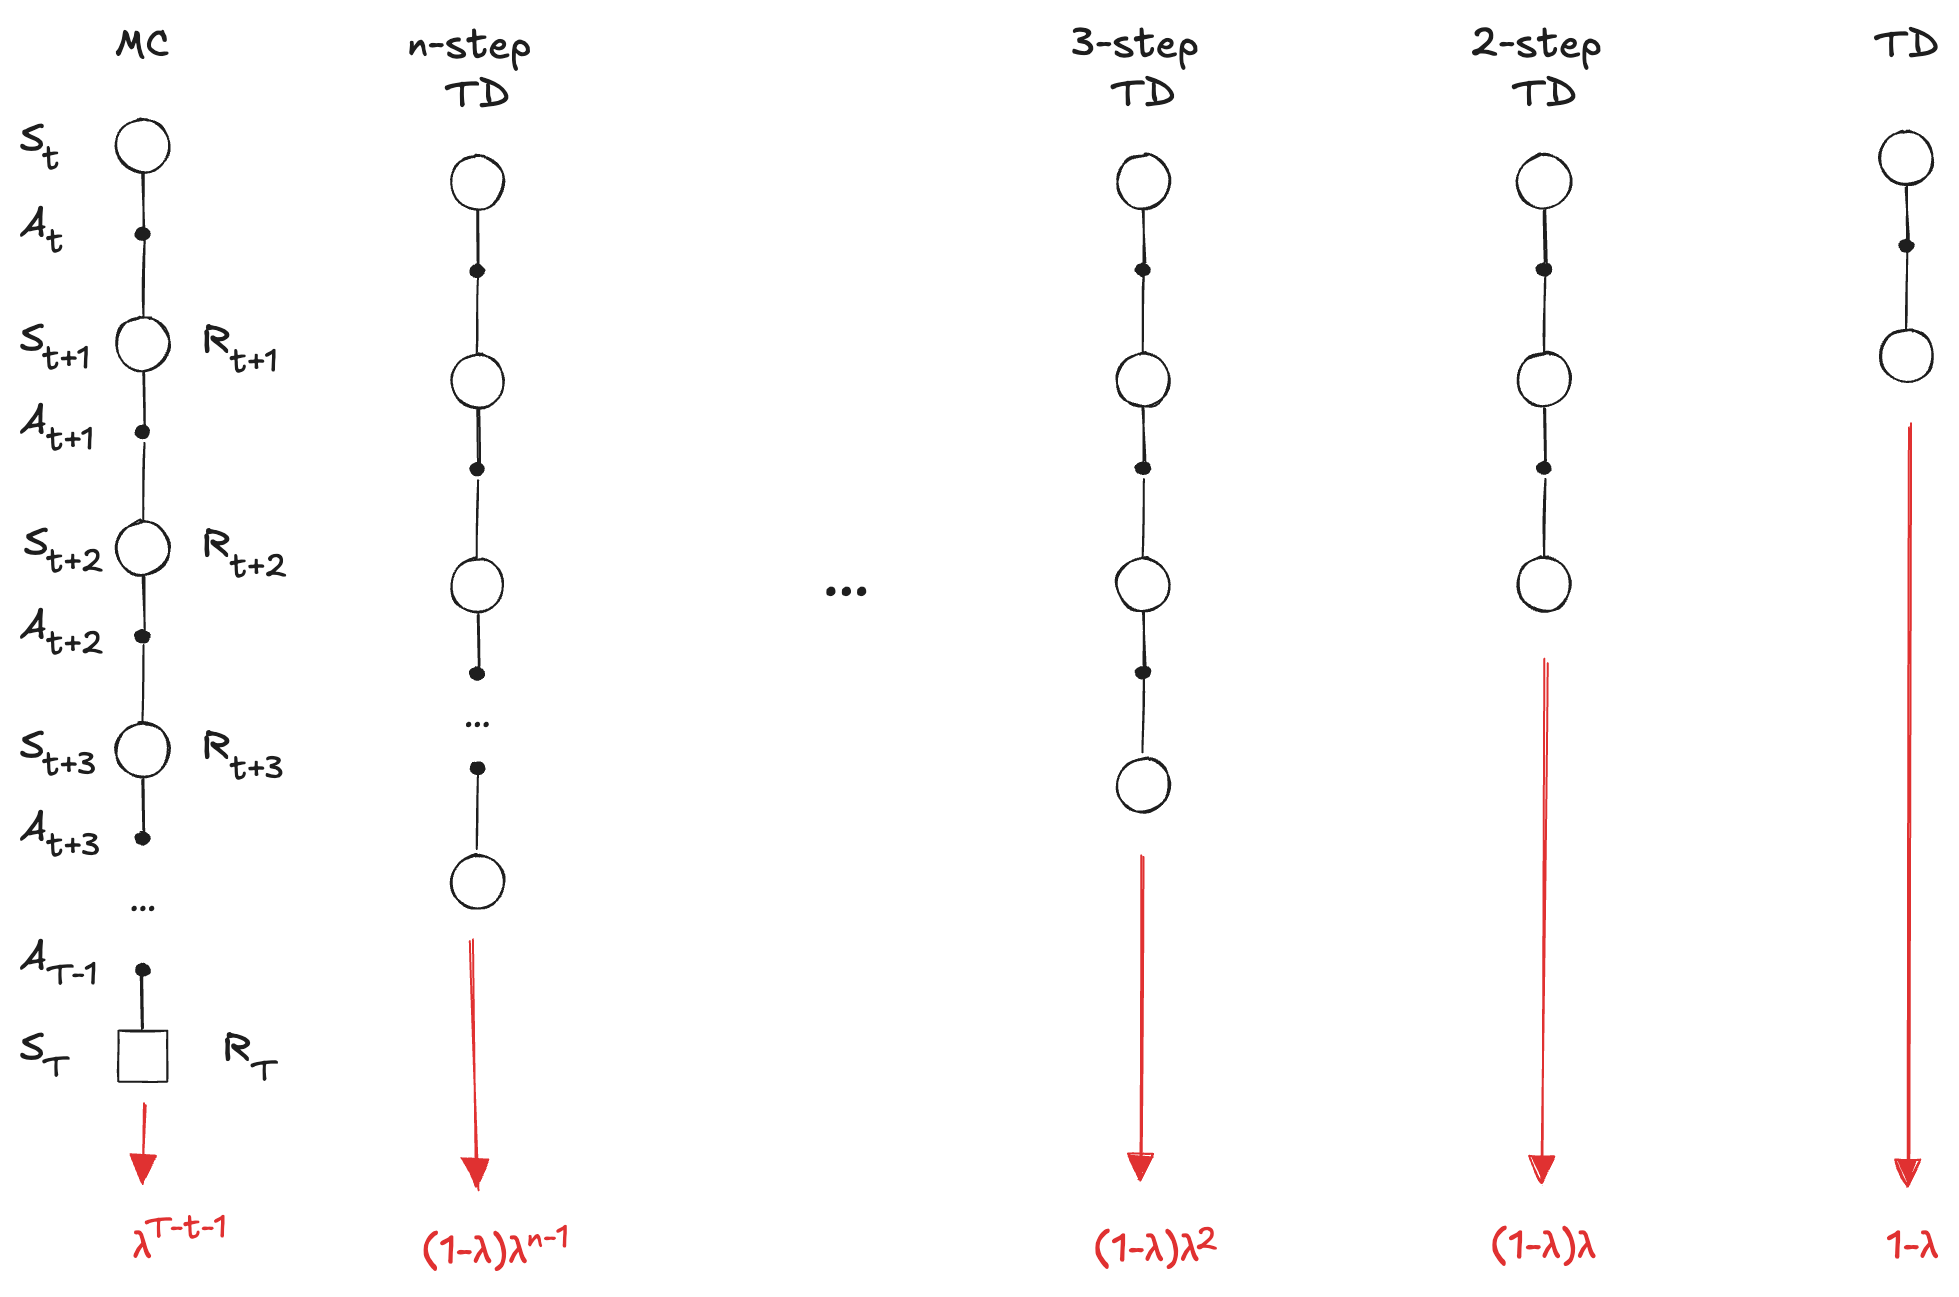

The parameter

$\displaystyle \lambda\in[0,1]$

controls how much weight is given to short versus long returns:

$\displaystyle \lambda=0\quad\Rightarrow\quad\text{TD(0)}$      
$\displaystyle 0<\lambda<1\quad\Rightarrow\quad\text{mixture of multiple }n\text{-step targets}$  
$\displaystyle \lambda=1\quad\Rightarrow\quad\text{Monte Carlo behavior}$

Recall the sequence of targets:

$\displaystyle G_{t:t+1}=R_{t+1}+\gamma V(S_{t+1})$     
$\displaystyle G_{t:t+2}=R_{t+1}+\gamma R_{t+2}+\gamma^2V(S_{t+2})$     
$\displaystyle G_{t:t+3}=R_{t+1}+\gamma R_{t+2}+\gamma^2R_{t+3}+\gamma^3V(S_{t+3})$     
$\displaystyle \vdots$      
$\displaystyle G_{t:t+n}=R_{t+1}+\gamma R_{t+2}+\cdots+\gamma^{n-1}R_{t+n}+\gamma^nV(S_{t+n})$  

until the complete Monte Carlo return:

$\displaystyle G_{t:T}=R_{t+1}+\gamma R_{t+2}+\cdots+\gamma^{T-t-1}R_T$     

TD($\lambda$) combines these targets using **exponentially decaying weights**:

$\displaystyle \boxed{G^\lambda_{t:T}=(1-\lambda)\sum_{n=1}^{T-t-1}\lambda^{n-1}G_{t:t+n}+\lambda^{T-t-1}G_{t:T}}$

The weights are therefore: 

$\displaystyle 1-\lambda,\quad(1-\lambda)\lambda,\quad(1-\lambda)\lambda^2,\quad\ldots$

for the 1-step, 2-step, 3-step, … targets.

Their meaning is simple: shorter targets receive more weight, while longer targets receive exponentially less weight. The parameter controls **how quickly that decay happens**. Small value concentrates most of the weight on short-horizon targets, so the method behaves more like TD(0). Large values spread more weight toward long-horizon targets, so the method behaves more like Monte Carlo. The Monte Carlo term is different:

$\displaystyle \lambda^{T-t-1}G_{t:T}$

because it receives **all the remaining weight once the episode terminates**. There is no later target beyond the terminal state, so the residual probability mass that would otherwise continue along the geometric sequence is assigned to the complete return. This is what makes all weights sum to one. The value estimate is then updated toward the $\lambda$-return:

$\displaystyle \boxed{V(S_t)\leftarrow V(S_t)+\alpha\underbrace{\left[\underbrace{G^\lambda_{t:T}}_{\text{TD}(\lambda)\text{ target}}-V(S_t)\right]}_{\text{TD}(\lambda)\text{ error}}}$

This is the **forward view**: from each visited state, we look forward, construct all possible n-step targets, and combine them into a single target. The **limitation is practical**: to compute the complete return, we need to know how the episode ends. In this offline form, we must therefore **wait until termination before performing the update**. The next question is therefore: can we obtain the same effect online, one transition at a time? This leads to the backward view and eligibility traces.

### The Backward View: Eligibility Traces

The practical implementation uses a **backward view** based on **eligibility traces**. Instead of standing at state $S_t$ and asking which future rewards should affect it, we reverse the perspective. At every new transition, we compute the ordinary one-step TD error and ask:** which previously visited states should receive credit for this new information?** An eligibility trace is a short-term memory associated with each state. Recently visited states have high eligibility; as time passes, their eligibility progressively decays. 

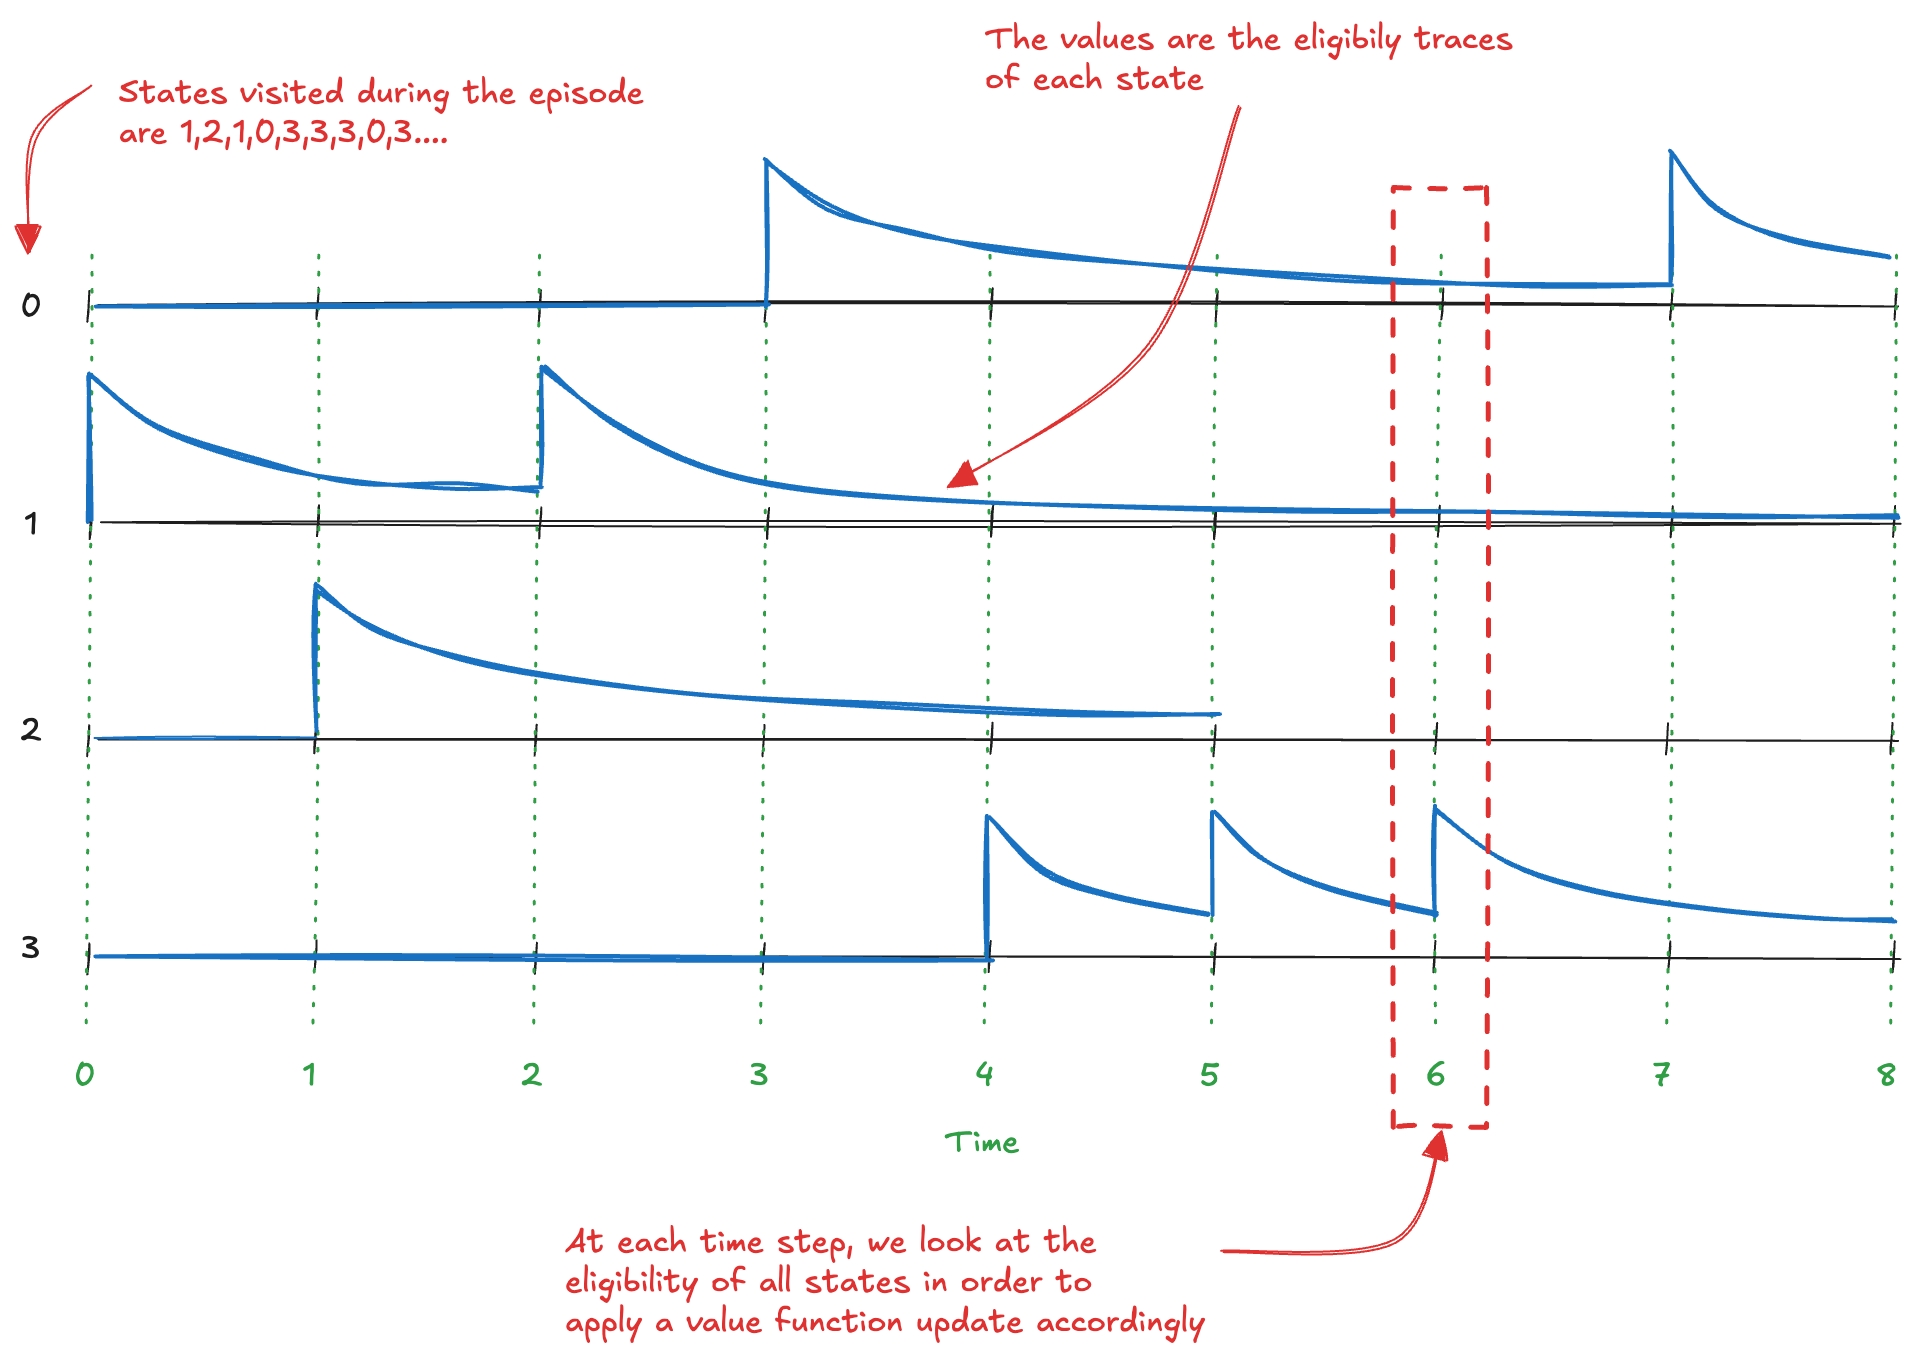

At the beginning of every episode, all traces are initialized to zero:

$\displaystyle E(s)=0\qquad\forall s$

We then interact with the environment for one step:

$\displaystyle S_t,A_t,R_{t+1},S_{t+1}$

When state $S_t$ is visited, we increase its eligibility:

$\displaystyle E(S_t)\leftarrow E(S_t)+1$

This is called an **accumulating trace**: if the same state is visited repeatedly, its eligibility can become larger than one. We then compute the usual one-step TD error:

$\displaystyle \delta_t=R_{t+1}+\gamma V(S_{t+1})-V(S_t)$

The crucial difference from TD(0) is what we do with this error. TD(0) uses $\delta_t$ to update only the current state. TD($\lambda$) propagates the same TD error backward to all eligible states:

$\displaystyle \boxed{V\leftarrow V+\alpha\,\delta_t E}$

Here V and E are vectors. Therefore, every state with a non-zero eligibility trace receives part of the update:

$\displaystyle V(s)\leftarrow V(s)+\alpha\,\delta_t E(s)$

Recently visited states receive a larger update because their eligibility is larger, states visited further in the past receive progressively less credit. After the update, the traces decay:

$\displaystyle E\leftarrow\gamma\lambda E$

This equation reveals the role of $\lambda$ particularly clearly. A small value makes traces disappear quickly, so TD errors are propagated only a short distance into the past. A large value keeps states eligible for longer, allowing new information to propagate much further backward along the trajectory. The complete interaction therefore follows a simple cycle:

$\displaystyle \text{visit state}\,\rightarrow\,\text{increase eligibility}\,\rightarrow\,\text{compute TD error}\,\rightarrow\,\text{update eligible states}\,\rightarrow\,\text{decay traces}$

This is the **backward view** of TD($\lambda$). Rather than explicitly constructing many future n-step returns, it uses the current TD error together with a fading memory of past states. We can implement accumulating-trace as follows:

In [26]:
def td_lambda(pi, env, gamma=1.0, lambda_=0.3,
              alpha=0.1, n_episodes=500):

    # Initialize the state-value estimates
    v = np.zeros(env.observation_space, dtype=float)

    # Store the estimates after each episode
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float)

    # Eligibility trace associated with every state
    E = np.zeros(env.observation_space, dtype=float)

    # Run one complete episode at a time
    for e in range(n_episodes):

        # Eligibility traces are reset at the beginning of each episode
        E.fill(0)

        state = env.reset()
        done = False

        while not done:

            # Select an action according to the policy
            action = pi(state)

            # Interact with the environment for one step
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            # Compute the ordinary one-step TD target and error
            td_target = reward + gamma * v[next_state] * (not done)
            td_error = td_target - v[state]

            # Make the current state eligible for credit
            E[state] = E[state] + 1

            # Propagate the current TD error to all eligible states
            v = v + alpha * td_error * E

            # Decay the eligibility traces
            E = gamma * lambda_ * E

            # Continue from the next state
            state = next_state

        # Store the value estimates after the episode
        v_track[e] = v

    return v.copy(), v_track

Notice the key difference from ordinary TD(0). The TD error is still computed from one transition:

$\displaystyle \delta_t=R_{t+1}+\gamma V(S_{t+1})-V(S_t)$

but that error is no longer used only for $S_t$. Through the eligibility traces, one TD error can update many states visited earlier in the trajectory. This is why TD($\lambda$) can propagate information much more rapidly through a sequence of states while still operating online. We can apply it to the Random Walk environment:

In [27]:
v_td_lambda, v_td_lambda_track = td_lambda(
    pi,
    random_walk,
    lambda_=0.3,
    n_episodes=500
)

print('State   TD(lambda)   True value')
print('--------------------------------')
for s in range(1, 6):
    print(f'{s:^5}   {v_td_lambda[s]:^10.3f}   {random_walk.v_true[s]:^10.3f}')

State   TD(lambda)   True value
--------------------------------
  1       0.117        0.167   
  2       0.289        0.333   
  3       0.592        0.500   
  4       0.779        0.667   
  5       0.892        0.833   


and visualize the evolution of the estimates:

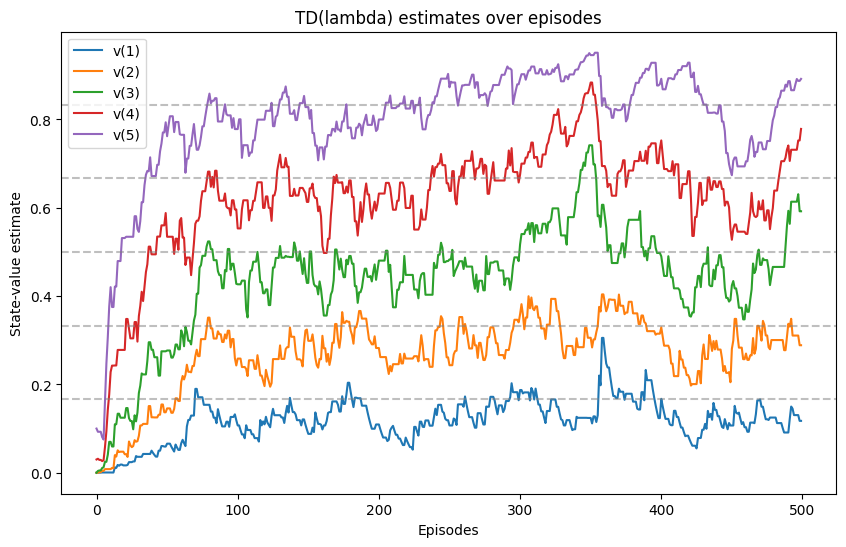

In [28]:
plt.figure(figsize=(10, 6))

plt.plot(v_td_lambda_track[:, 1:6])

# Plot the true state values
plt.axhline(random_walk.v_true[1], color='gray', linestyle='--', alpha=0.5)
plt.axhline(random_walk.v_true[2], color='gray', linestyle='--', alpha=0.5)
plt.axhline(random_walk.v_true[3], color='gray', linestyle='--', alpha=0.5)
plt.axhline(random_walk.v_true[4], color='gray', linestyle='--', alpha=0.5)
plt.axhline(random_walk.v_true[5], color='gray', linestyle='--', alpha=0.5)

plt.title('TD(lambda) estimates over episodes')
plt.xlabel('Episodes')
plt.ylabel('State-value estimate')
plt.legend(['v(1)', 'v(2)', 'v(3)', 'v(4)', 'v(5)'])

plt.show()

Finally, we can compare its learning curve with MC and TD(0):

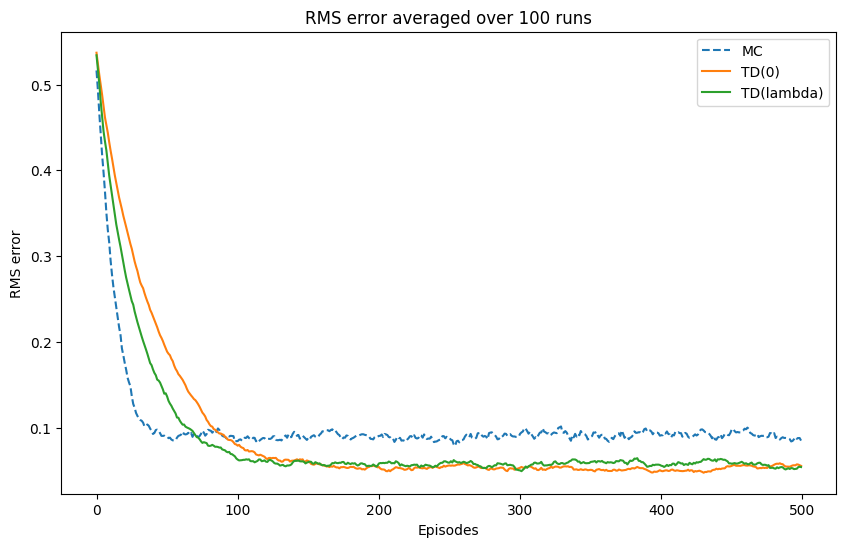

In [29]:
rmse_td_lambda = run_experiment(td_lambda, 100, random_walk, pi)

plt.figure(figsize=(10, 6))
plt.plot(rmse_mc, linestyle='--', label='MC')
plt.plot(rmse_td, label='TD(0)')
plt.plot(rmse_td_lambda, label='TD(lambda)')
plt.title('RMS error averaged over 100 runs')
plt.xlabel('Episodes')
plt.ylabel('RMS error')
plt.legend()
plt.show()

For the particular Random Walk experiment and the selected hyperparameters, TD($\lambda$) may achieve a lower error than either MC or TD(0). The important conclusion, however, is not that it is universally better. Rather, the methos gives us a **continuous mechanism for controlling how far credit propagates through time**. Increasing $\lambda$ allows each TD error to affect states progressively further into the past. At $\lambda=1$, the method approaches Monte Carlo behavior while retaining an incremental, online implementation.  This is the key conceptual advantage of eligibility traces: instead of choosing a single temporal horizon$n, TD($\lambda$) combines information across multiple horizons and efficiently assigns new information backward to previously visited states.

## Policy Improvement

So far, we have focused on policy evaluation: given a fixed policy, how good is it? We answered this question by estimating its value function, which tells us the expected return from each state. But evaluating a policy does not improve it. Once we know how good different choices are, we need to use that information to make better decisions. The basic idea of policy improvement is to make the policy greedier with respect to the current value estimates. In each state, we prefer the action with the highest action value:

$\displaystyle \boxed{\pi_{k+1}(s)=\underset{a}{\arg\max}\,q_{\pi_k}(s,a)}$

This is the same principle used in Policy Iteration with Dynamic Programming: evaluate the current policy, improve it using the resulting values, evaluate the new policy, and repeat:

$\displaystyle \pi_0 \overset{\text{evaluate}}{\longrightarrow} q_{\pi_0} \overset{\text{improve}}{\longrightarrow} \pi_1 \overset{\text{evaluate}}{\longrightarrow} q_{\pi_1} \overset{\text{improve}}{\longrightarrow} \pi_2 \overset{\text{evaluate}}{\longrightarrow}\cdots\overset{\text{improve}}{\longrightarrow}\pi_*$

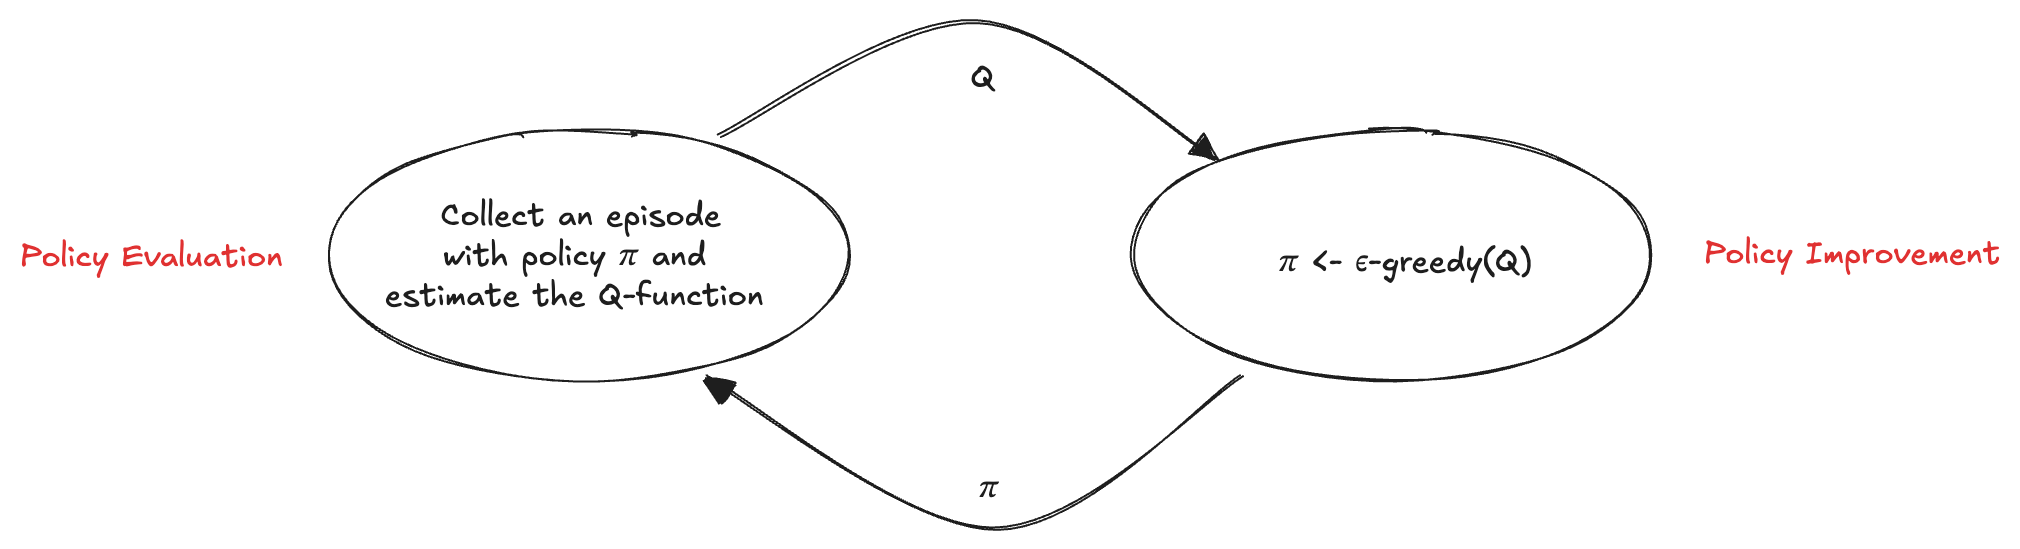

There is, however, a **fundamental difference**. In Dynamic Programming, we could evaluate and improve policies using a known model of the environment. In reinforcement learning, the model is unknown: **values must instead be learned from sampled experience**. The two processes therefore interact continuously: evaluation learns how good the current behavior is, while improvement uses those estimates to produce better behavior. We do not even need to wait for either process to finish before starting the other. This general interaction between policy evaluation and policy improvement is called **Generalized Policy Iteration (GPI)**. It provides a common architecture for a large class of reinforcement learning algorithms: values are continually adjusted to better predict returns, while the policy is continually adjusted to become better with respect to those values.

### Slippery Walk environment

We use an environment called **Slippery Walk**. This environment is a walk, a single-row grid-world environment, with seven non-terminal states. The particular thing of this environment is that it’s slippery, like the Fronzen Lake: **action effects are stochastic**. If the agent chooses to go left, there is a chance it does, but there is also a chance that it goes right, or that it stays in place.

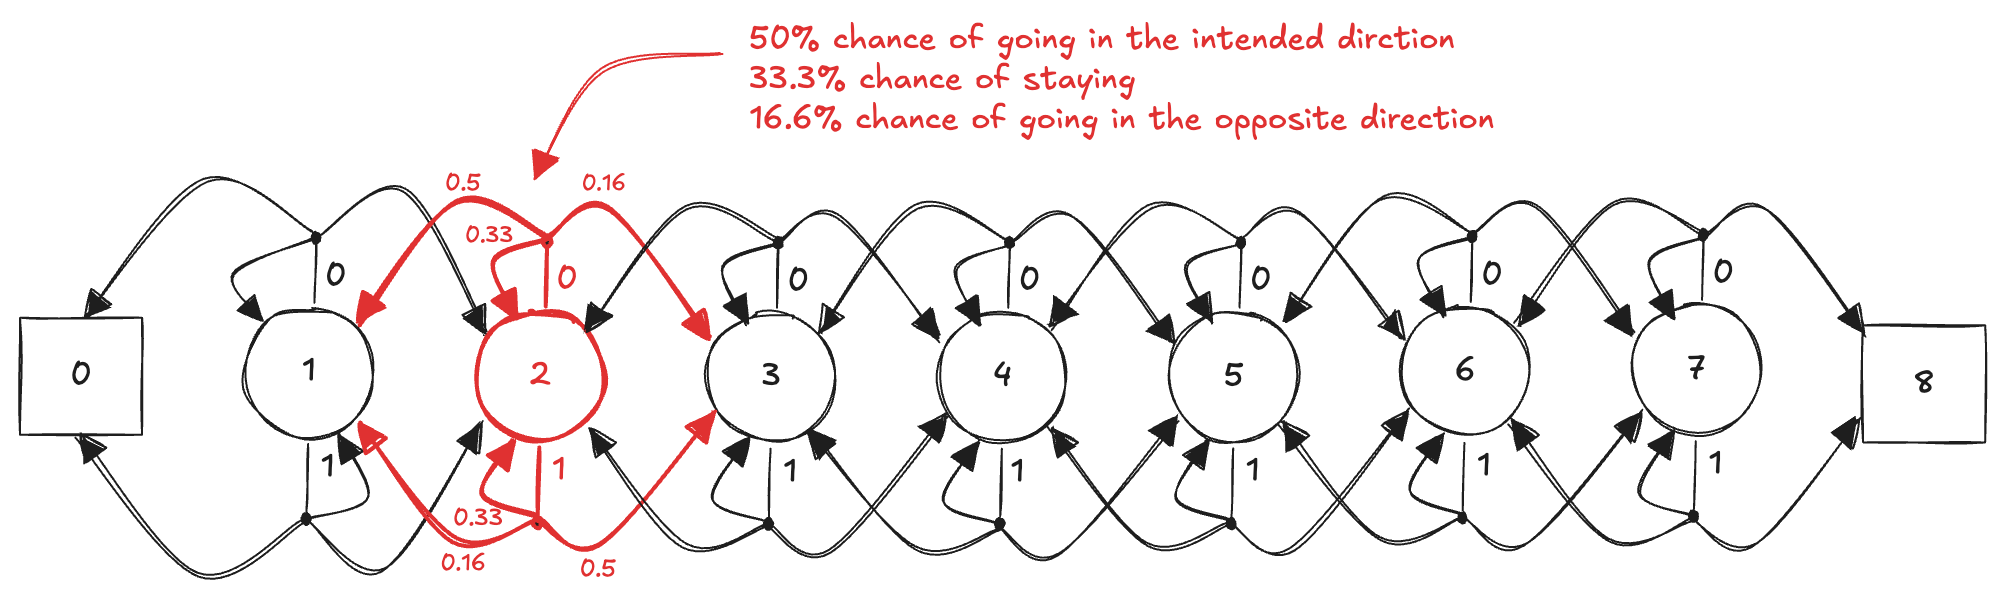

This environment is noisy, but the actions the agent selects make a difference in its performance.

In [1]:
import random
import numpy as np
        
class SlipperyWalk:
    def __init__(self):
        self.reset();

    def reset(self):
        self.observation_space = 9;
        self.action_space = 2;
        self.state = np.random.choice([1,2,3,4,5,6,7]);
        self.terminated = False;
        return self.state;

    def step(self, action):
        if self.terminated: raise ValueError('Episode has terminated');
        if action not in [0, 1]: raise ValueError('Invalid action');
        
        if(action==0): direction = -1;
        if(action==1): direction = 1;
        
        direction_list = [direction, -direction, 0];
        true_direction = random.choices(direction_list, weights=(50, 16, 33), k=1);
        self.state += true_direction[0];
        
        reward = 0
        if self.state < 1: 
            self.terminated = True;
        if self.state > 7: 
            self.terminated = True; 
            reward = 1;
        
        return self.state, reward, self.terminated, 0, 0;

In [2]:
slippery_walk = SlipperyWalk()

The optimal state value function can be calculated using the MDP and applying the Dynamic Programming:

In [3]:
optimal_v = [0., 0.5637, 0.763, 0.8449, 0.8892, 0.922, 0.9515, 0.9806, 0.];

### Improving policies after each episode: Monte Carlo control

The **policy improvement theorem** (as already considered in Dynamic Programming) assures that each new policy is better than (or just as good as) the previous one, so the overall process converges to the optimal policy and optimal value function:

$\displaystyle q_{\pi_k}(s, \pi_{k+1}(s)) = q_{\pi_k}(s, \underset{a}{\arg \max}\> q_{\pi_k}(s,a)) 
 = \underset{a}{\max \>} q_{\pi_k}(s,a)) \geq q_{\pi_k}(s, \pi_k(s)) \geq v_{\pi_k}(s)$

In order to implement this idea, we need to **estimates the action-value function, instead of the state-value function**, in order to know what the best action is to take from a state:

$\displaystyle Q(S_t, A_t) = Q(S_t, A_t) + \alpha [G_{t:T} - Q(S_t, A_t)]$

Then, we need to **explore**, becouse we’re no longer using the MDP for the policy-evaluation. When we estimate from samples, we get values for all of the state-action pairs we visited, but what if part of the best states weren’t visited? Let’s start using **first-visit Monte Carlo** for the policy-evaluation phase and a **decaying epsilon-greedy action-selection strategy** for the policy-improvement phase:

In [4]:
def select_action(state, q, epsilon=0.1):

    # if the random number is greater than epsilon, 
    if np.random.uniform() > epsilon:
        # pick the action with the highest Q value
        action = np.argmax(q[state]);
    else:
        # otherwise, pick a random action
        action = np.random.randint(len(q[0]));

    return action;

In control the targets are non-stationary for a stronger reason than in prediction: the policy that generates them keeps changing, so early experience is collected under a policy far from the final one. We therefore abandon the constant step size used for prediction and let $\alpha$ **decay** over the episodes, quickly at the beginning and more slowly later. The same schedule is used for $\varepsilon$, so that exploration is progressively replaced by exploitation. We build it with NumPy's "logspace" function, starting from an initial value and decreasing toward a minimum value over a given fraction of the episodes:

In [5]:
def decay_schedule(init_value, min_value, decay_steps, max_steps):

    # calculate the number of the remaining steps after the decay
    rem_steps = max_steps - decay_steps;

    # logspace returns numbers spaced evenly on a log scale
    # base^start is the starting value of the sequence,
    # base^stop is the final value of the sequence
    # num is the number of values to generate
    # base is the base of the log space
    values = np.logspace(start=0, stop=-2, num=decay_steps, base=10);

    # because the values may not end exactly at 0, given it’s the log, 
    # we change them to be between 0 and 1 so that the curve looks smooth and nice.
    values = (values - values.min()) / (values.max() - values.min());

    # linear transformation and get points between init_value and min_value
    values = (init_value - min_value) * values + min_value;

    # repeats the rightmost value rem_step number of times
    values = np.pad(values, (0, rem_steps), 'edge');

    return values;

The generation of a trajectory is slightly different from Part I: the action is no longer given by a fixed policy, but selected by an exploration strategy on the current $Q$ estimates, so we define a separate `generate_trajectory_control`:

In [7]:
def generate_trajectory_control(select_action, q, env, epsilon, max_steps=200):

    # list of experiences (trajectory)
    trajectory = [];

    done = False;
    steps = 0;

    # reset the environment to interact in a new episode
    state = env.reset();

    # looping through until the done flag is set to true
    while not done:
        steps += 1; 

        # there is the difference: use the 'select_action' 
        # function to pick an action
        action = select_action(state, q, epsilon);
            
        # step the environment using that action
        next_state, reward, terminated, truncated, info = env.step(action);
        if(terminated or truncated):
            done = True;

        # append the experience to the trajectory
        experience = (state, action, reward, next_state, done);
        trajectory.append(experience);
        
         # if we hit a terminal state break and return
        if done:
            break;

        # truncate long trajectories 
        if steps >= max_steps:
            break;   
       
        # update the state
        state = next_state;
    
    # return the trajectory
    return np.array(trajectory, object);

Then we can write the Monte Carlo control algorithm, which is similar to one for prediction. The two main differences is that we now estimate the action-value function, and we need to explore (we use an decaying epsilon to control random exploration):

In [ ]:
def mc_control(env, gamma=0.99, 
               init_alpha=0.5, min_alpha=0.01, 
               init_epsilon=1.0, min_epsilon=0.1, 
               decay_episodes=1000, n_episodes=3000, 
               max_steps=200):
    
    # calculate all alphas at once
    alphas = decay_schedule(init_alpha, min_alpha, decay_episodes, n_episodes);
        
    # calculate all epsilons in advance
    epsilons = decay_schedule(init_epsilon, min_epsilon, decay_episodes, n_episodes);

    # initialize the current estimate of the action-value function
    q = np.zeros((env.observation_space, env.action_space), dtype=float);
    
    # create a list to save copies of v for offline analysis
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float);
    
    # the episode loop    
    for e in range(n_episodes):
        
        # generate a trajectory using the exploratory policy
        trajectory = generate_trajectory_control(select_action, q, env, epsilons[e], max_steps);
        
        # calculate the return of every step of the trajectory in a single backward pass
        returns = compute_returns(trajectory[:, 2], gamma);
        
        # initialize a visits check vector
        visited = np.zeros((env.observation_space, env.action_space), dtype=bool);
        
        # loop through all experiences in the trajectory
        for t, (state, action, reward, _, _) in enumerate(trajectory):
            
            # check if the state-action has already been visited (first-visit MC)
            if visited[state][action]: 
                continue;
            visited[state][action] = True;
            
            # estimate the value functions
            q[state][action] = q[state][action] + alphas[e] * (returns[t] - q[state][action]);

        # extract the state-value function   
        v = np.max(q, axis=1);

        # and the greedy policy
        def pi(s):
            return np.argmax(q[s]);

        # save values for post analysis
        v_track[e] = v;
    
    return q, v, pi, v_track;

Let’s test the algorithm in the Slippery Walk Seven environment: 

In [10]:
q_mc, v_mc, pi_mc, v_track_mc = mc_control(slippery_walk);

We can show the estimates over episodes:

In [11]:
print(v_mc)

[0.         0.52589139 0.75560115 0.82772955 0.89103973 0.92836406
 0.95409788 0.98320711 0.        ]


Of course, the optimal policy learned is obvious in this case, but the algorithm is able to learn it:

In [12]:
def print_policy(pi, env):
    for state in range(env.observation_space):
        action = pi(state)
        action_icon = ' '
        if action == 0: action_icon = 'L'
        if action == 1: action_icon = 'R'
        print('state:', state, '->', 'action:', action_icon)

In [13]:
print_policy(pi_mc, slippery_walk)

state: 0 -> action: L
state: 1 -> action: R
state: 2 -> action: R
state: 3 -> action: R
state: 4 -> action: R
state: 5 -> action: R
state: 6 -> action: R
state: 7 -> action: R
state: 8 -> action: L


We can show the difference between the estimates and the real values:

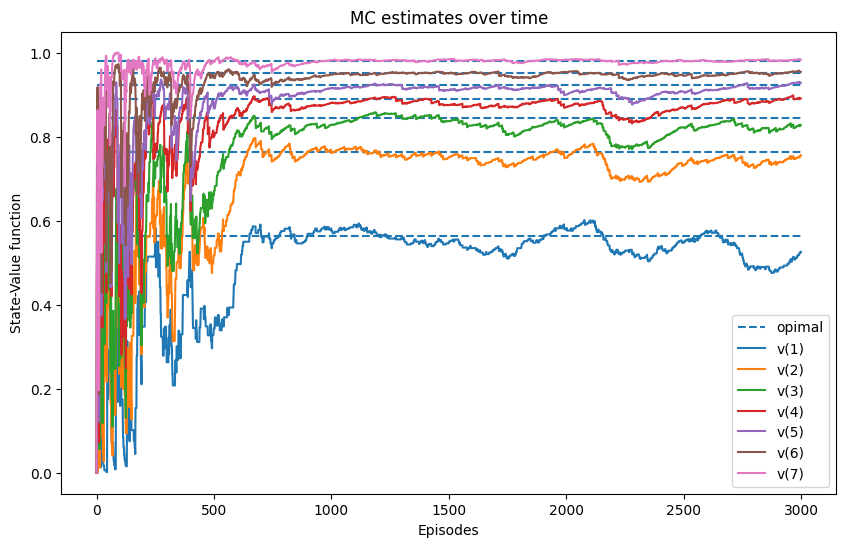

In [14]:
import matplotlib.pyplot as plt

legends = ['opimal', 'v(1)','v(2)','v(3)','v(4)','v(5)', 'v(6)', 'v(7)'];
plt.figure(figsize=(10,6));
plt.hlines(optimal_v[1:8], 0, 3000, linestyle='--');
plt.plot(v_track_mc[:,1:8]);
plt.title('MC estimates over time');
plt.ylabel('State-Value function');
plt.xlabel('Episodes');
plt.legend(legends);
plt.show();

Notice how **the estimates of MC have high variance**. We can use a brute-force approach to get the average return of the policy and its success probability.

In [12]:
def evaluate(env, pi, n_episodes=1000, max_steps=200):
    success = 0;
    results = [];
    for _ in range(n_episodes):
        done = False;
        steps = 0;
        state = env.reset();
        results.append(0.0);
        while not done and steps < max_steps:
            state, reward, terminated, truncated, info = env.step(pi(state));
            if(terminated or truncated):
                done = True;
            results[-1] += reward;
            steps += 1;
        if(done and reward==1):
            success += 1;
    return (success/n_episodes)*100, np.mean(results);

In [13]:
probability_success_mc, mean_return_mc = evaluate(slippery_walk, pi_mc);

print("Reaches goal ", probability_success_mc, "%");
print("Obtains an average undiscounted return of ", mean_return_mc);

Reaches goal  93.30000000000001 %
Obtains an average undiscounted return of  0.933


### Improving policies after each step: SARSA

Monte Carlo method is an **offline** method in an episode-to-episode sense: we must wait until a terminal state before we can make any improvements to the value function estimate. So, it is straightforward to apply **temporal-difference prediction** for the policy-evaluation phase in order to remove this limitation. The algorithm is called **SARSA agent** ([Rummery & Niranjan, "Online Q-Learning using Connectionist Systems" (1994)](./papers/1994%20-%20Online%20Q-Learning%20using%20Connectionist%20Systems.pdf):

$\displaystyle G_{t:t+1} = R_{t+1} + \gamma Q(S_{t+1}, A_{t+1})$

We can substitute in the formula for the evaluation of the action-value function:

$\displaystyle Q(S_t, A_t) = Q(S_t, A_t) + \alpha_t [G_{t:t+1} - Q(S_t, A_t)]$

where $G_{t:t+1}$ is the **SARSA target** and $G_{t:t+1} - Q(S_t, A_t)$ is the **SARSA error**.

We can implement it in Python:

In [15]:
def sarsa(env, gamma=0.99, 
          init_alpha=0.5, min_alpha=0.01, 
          init_epsilon=1.0, min_epsilon=0.1, 
          decay_episodes=1000, n_episodes=3000):
    
    # calculate the learning rate schedule for all episodes    
    alphas = decay_schedule(init_alpha, min_alpha, decay_episodes, n_episodes);

    # calculate epsilon for all episodes   
    epsilons = decay_schedule(init_epsilon, min_epsilon, decay_episodes, n_episodes);

    # initialize the current estimate of the action-value function
    q = np.zeros((env.observation_space, env.action_space), dtype=float);
    
    # create a list to save copies of v for offline analysis
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float);

    # the episode loop    
    for e in range(n_episodes):
        
        # we start episode by resetting the environment and the done flag
        state, done = env.reset(), False;
        
        # select the action (perhaps exploratory) for the initial state
        action = select_action(state, q, epsilons[e]);
        
        # repeat until we hit a terminal state
        while not done:
            
            # step the environment using that action
            next_state, reward, terminated, truncated, info = env.step(action);
            if(terminated or truncated):
                done = True;
            
            # obtain the action for the next step
            next_action = select_action(next_state, q, epsilons[e]);
            
            # calculate the target using that next state-action pair
            sarsa_target = reward + gamma * q[next_state][next_action]
            
            # calculate the error                                   
            sarsa_error = sarsa_target - q[state][action];
            
            # update the action-value function
            q[state][action] = q[state][action] + alphas[e] * sarsa_error;
                        
            # update state and action for the next step
            state, action = next_state, next_action;
            
        # extract the state-value function   
        v = np.max(q, axis=1);

        # and the greedy policy
        def pi(s):
            return np.argmax(q[s]);

        # save values for post analysis   
        v_track[e] = v;
    
    return q, v, pi, v_track;

Now we can run SARSA against the  Slippery Walk environment:

In [16]:
q_sarsa, v_sarsa, pi_sarsa, v_track_sarsa = sarsa(slippery_walk);

In [17]:
print(v_sarsa);

[0.         0.52063677 0.71702406 0.81401339 0.86784435 0.90884011
 0.94304096 0.97815134 0.        ]


We can show the estimates over episodes and the difference between the estimates and the real values:

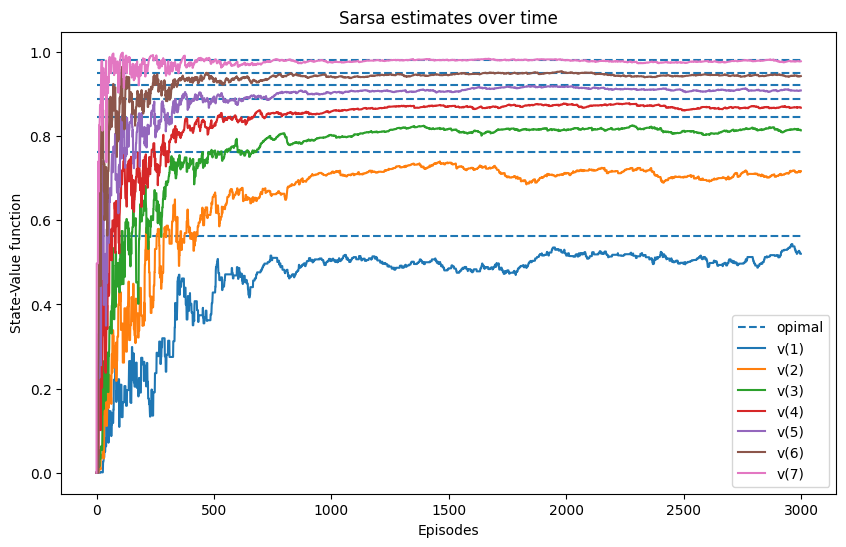

In [18]:
plt.figure(figsize=(10,6));
plt.hlines(optimal_v[1:8], 0, 3000, linestyle='--');
plt.plot(v_track_sarsa[:,1:8]);
plt.title('Sarsa estimates over time');
plt.ylabel('State-Value function');
plt.xlabel('Episodes');
plt.legend(legends);
plt.show();

We can see how SARSA has less variance than MC, but it slower to converge, particularly for low-value states. Again, we can use the brute-force approach to get the average return of the policy and its success probability:

In [18]:
probability_success_sarsa, mean_return_sarsa = evaluate(slippery_walk, pi_sarsa);

print("Reaches goal ", probability_success_sarsa, "%");
print("Obtains an average undiscounted return of ", mean_return_sarsa);

Reaches goal  93.30000000000001 %
Obtains an average undiscounted return of  0.933


Monte Carlo and SARSA must meet some requirements to guarantee convergence to the optimal policy: (a) **all state-action pairs must be explored infinitely often** and (b) **the policy must converge on a greedy policy**. In practice, this means that an the epsilon-greedy exploration strategy must slowly decay epsilon towards zero. If it goes down too quickly, the first condition may not be met; if it decays too slowly, well, it takes longer to converge.

### Decoupling behavior from learning: Q-Learning

The SARSA algorithm is a sort of "learning on the job", the agent learns the value of the policy it is currently following, which means it **evaluates and improves the same policy that it is using to make decisions**. The agent explores and exploits the environment according to the same policy it is updating. This type of learning is called **on-policy learning**. It is excellent, we learn from our own mistakes. But we learn from our own current mistakes only. What if we want to learn from our own previous mistakes? What if we want to learn from the mistakes of others? The **Off-policy learning** approach is sort of "learning from others": the agent **learns the value of an optimal policy, but it follows a different behavior policy to explore** the environment. In other words, it separates the policy it uses to explore (**behavior policy**) from the policy it is trying to optimize (**target policy**). The most used off-policy algorithm is called **Q-Learning** ([Watkins, "Learning from Delayed Rewards" (1989)](./papers/1989%20-%20Learning%20from%20Delayed%20Rewards.pdf). The difference between SARSA and Q-learning is the action used to calculate the target. SARSA uses the action taken in the next state, Q-learning uses the action with the maximum estimated value in the next state, despite the action taken:

$\displaystyle G_{t:t+1} = R_{t+1} + \gamma \underset{a}{\text{ max }} Q(S_{t+1}, a)$

We can substitute in the formula for the evaluation of the action-value function:

$\displaystyle Q(S_t, A_t) = Q(S_t, A_t) + \alpha_t [G_{t:t+1} - Q(S_t, A_t)]$

where $G_{t:t+1}$ is the **Q-learning target** and $G_{t:t+1} - Q(S_t, A_t)$ is the **Q-learning error**.

Q-Learning algorithm will evaluate all possible state-actions pairs and choose that pair which will generate maximum expected rewards (which is the value of the state). Off-policy methods can converge faster because they are not restricted by the exploration-exploitation balance of the behavior policy. We can implement it in Python:

In [19]:
def q_learning(env, gamma=0.99, 
               init_alpha=0.5, min_alpha=0.01, 
               init_epsilon=1.0, min_epsilon=0.1, 
               decay_episodes=1000, n_episodes=3000):
    
    # calculate the learning rate schedule for all episodes    
    alphas = decay_schedule(init_alpha, min_alpha, decay_episodes, n_episodes);

    # calculate epsilon for all episodes   
    epsilons = decay_schedule(init_epsilon, min_epsilon, decay_episodes, n_episodes);

    # initialize the current estimate of the action-value function
    q = np.zeros((env.observation_space, env.action_space), dtype=float);
    
    # create a list to save copies of v for offline analysis
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float);
    
    # the episode loop    
    for e in range(n_episodes):

        # we start episode by resetting the environment and the done flag
        state, done = env.reset(), False;

        # repeat until we hit a terminal state
        while not done:

            # select the action
            action = select_action(state, q, epsilons[e]);

            # step the environment using that action
            next_state, reward, terminated, truncated, info = env.step(action);
            if(terminated or truncated):
                done = True;
            
            # calculate the target: here is Q-learning!
            q_learning_target = reward + gamma * q[next_state].max();
            
            # calculate the error 
            q_learning_error = q_learning_target - q[state][action];

            # update the action-value function
            q[state][action] = q[state][action] + alphas[e] * q_learning_error;

            # update state for the next step
            state = next_state;

        # extract the state-value function   
        v = np.max(q, axis=1);

        # and the greedy policy
        def pi(s):
            return np.argmax(q[s]);
        
        # save values for post analysis   
        v_track[e] = v;

    return q, v, pi, v_track;

Now we can run Q-Learning against the  Slippery Walk environment:

In [20]:
q_ql, v_ql, pi_ql, v_track_ql = q_learning(slippery_walk);

In [21]:
print(v_ql)

[0.         0.57510604 0.77902023 0.8516414  0.89468035 0.92487707
 0.95390326 0.9799436  0.        ]


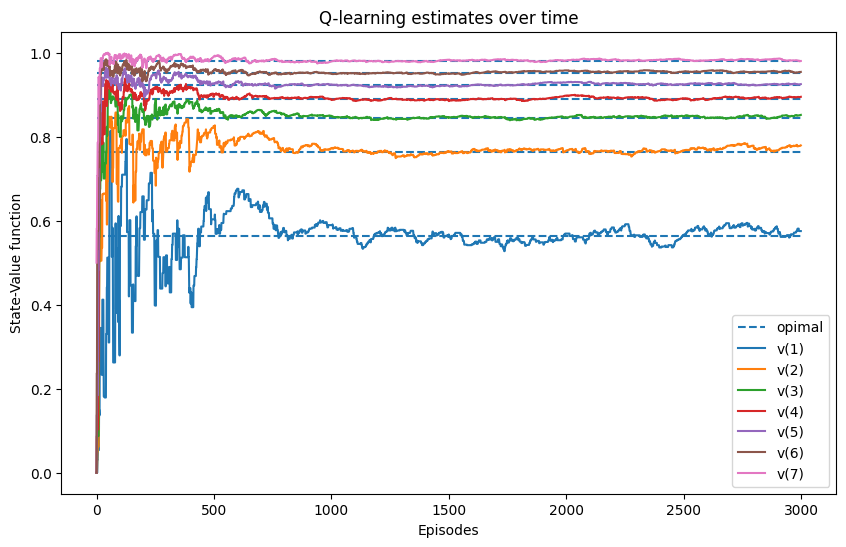

In [22]:
plt.figure(figsize=(10,6));
plt.hlines(optimal_v[1:8], 0, 3000, linestyle='--');
plt.plot(v_track_ql[:,1:8]);
plt.title('Q-learning estimates over time');
plt.ylabel('State-Value function');
plt.xlabel('Episodes');
plt.legend(legends);
plt.show();

See how much **faster** the estimates track the true values. But, also, notice how the estimates are often higher and **jump around** somewhat aggressively.

In [23]:
probability_success_ql, mean_return_ql = evaluate(slippery_walk, pi_ql);

print("Reaches goal ", probability_success_ql, "%");
print("Obtains an average undiscounted return of ", mean_return_ql);

Reaches goal  92.60000000000001 %
Obtains an average undiscounted return of  0.926


Notice that for off-policy algorithms the only requirement that holds of the two for convergence is the first one (all state-action pairs must be explored infinitely often). The second one (the policy must converge on a greedy policy) is no longer a requirement, because the learned policy is different than the one used to sampling actions.

### Solving the maximization bias: Double Q-Learning

Q-learning often **overestimates the value function**. On every step, we take the **maximum over the estimates** of the action-value function of the next state, but what we need is an **estimate of the maximum** of the action-value function of the next state. We are using the **maximum over estimates as an estimate of the maximum**. Consider the Q-learning update rule:

$\displaystyle G_{t:t+1} = R_{t+1} + \gamma \underset{a}{\text{ max }} Q(S_{t+1}, a)$

$\displaystyle Q(S_t, A_t) = Q(S_t, A_t) + \alpha_t [G_{t:t+1} - Q(S_t, A_t)]$

Here, the maximum over the estimates is used to select the action with the maximum estimated future reward. However, if the estimates of are noisy or imprecise (which is often the case early in training), the **maximization tends to select actions with overestimated values**. This leads to a systematic bias towards overestimating the value of the chosen actions. This is a problem known as **maximization bias**. Imagine an action-value function whose actual values are all zeros, but the estimates have errors (0.11, 0.65, –0.44, –0.26, and so on). We know the actual maximum is zero, but the maximum over the estimates is 0.65. One way of dealing with this is a technique called **double Q-learning** [Hasselt, Hado. "Double Q-learning." Advances in neural information processing systems NIPS (2010)](./papers/2010%20-%20Double%20Q-learning.pdf). In this approach, two separate action-value estimates are maintained, and the update rule is modified to reduce bias. One action-value function is used to select the action with the maximum value. The other action-value function is used to evaluate the value of that action, thus **breaking the dependence between action selection and value estimation**. This approach helps to reduce the overestimation problem by decoupling the action selection from the max operator, leading to more stable and accurate learning. The issue, though, is now we are splitting the experience between two separate functions and this somewhat **slows down training**. Other Methods, like **Weighted Q-learning** and **softmax selection** can also mitigate the bias, though they are less common compared to Double Q-learning. We can implement the idea in Python:

In [23]:
def double_q_learning(env, gamma=0.99, 
                      init_alpha=0.5, min_alpha=0.01, 
                      init_epsilon=1.0, min_epsilon=0.1, 
                      decay_episodes=1000, n_episodes=3000):
    
    # calculate the learning rate schedule for all episodes    
    alphas = decay_schedule(init_alpha, min_alpha, decay_episodes, n_episodes);

    # calculate epsilon for all episodes   
    epsilons = decay_schedule(init_epsilon, min_epsilon, decay_episodes, n_episodes);

    # initialize the two action-value functions
    q1 = np.zeros((env.observation_space, env.action_space), dtype=float);
    q2 = np.zeros((env.observation_space, env.action_space), dtype=float);

    # create a list to save copies of v for offline analysis
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float);
    
    # the episode loop    
    for e in range(n_episodes):

        # we start episode by resetting the environment and the done flag
        state, done = env.reset(), False;

        # repeat until we hit a terminal state
        while not done:
            
            # we use the mean of our two action-value functions to select action 
            action = select_action(state, (q1 + q2)/2., epsilons[e]);

            # step the environment using that action
            next_state, reward, terminated, truncated, info = env.step(action);
            if(terminated or truncated):
                done = True;
            
            # flip a coin to determine an update to q1 or q2
            if np.random.randint(2):

                # use the action q1 thinks is best...
                argmax_q1 = np.argmax(q1[next_state]);
                
                # ...but get the value from q2 to calculate the target
                dq_learning_target = reward + gamma * q2[next_state][argmax_q1];

                # calculate the error 
                dq_learning_error = dq_learning_target - q1[state][action];
                
                # update q1
                q1[state][action] = q1[state][action] + alphas[e] * dq_learning_error;

            else:
                
                # use the action q2 thinks is best...
                argmax_q2 = np.argmax(q2[next_state]);
                
                # ...but get the value from q1 to calculate the target
                dq_learning_target = reward + gamma * q1[next_state][argmax_q2];
                dq_learning_error = dq_learning_target - q2[state][action];
                
                # update q2
                q2[state][action] = q2[state][action] + alphas[e] * dq_learning_error;
            
            # update state
            state = next_state;
        
        # extract the value functions
        q = (q1 + q2)/2.;
        v = np.max(q, axis=1);

        # and the greedy policy
        def pi(s):
            return np.argmax(q[s]);
        
        # save values for post analysis
        v_track[e] = v
    
    return q, v, pi, v_track;

Now we can run Double Q-Learning against the  Slippery Walk environment:

In [24]:
q_dql, v_dql, pi_dql, v_track_dql = double_q_learning(slippery_walk);

In [26]:
print(v_dql)

[0.         0.58634552 0.7786524  0.85104747 0.89197395 0.92670831
 0.95368596 0.98076035 0.        ]


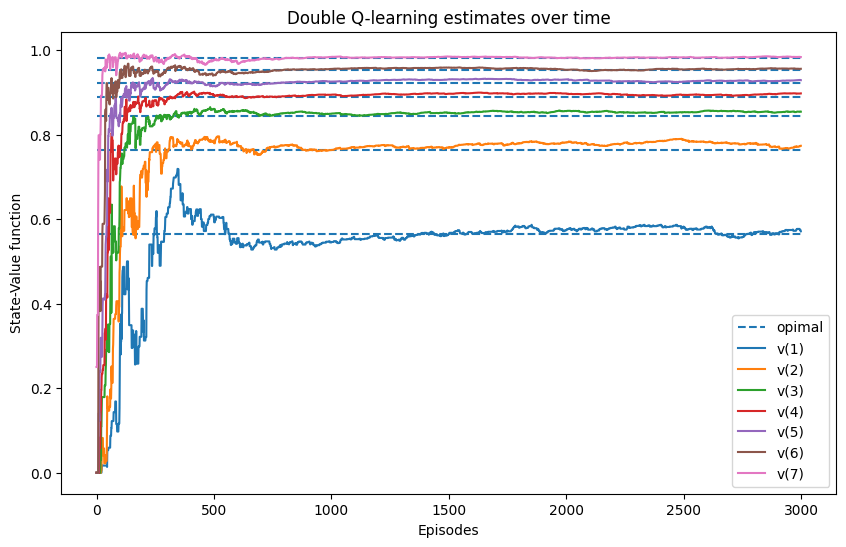

In [25]:
plt.figure(figsize=(10,6));
plt.hlines(optimal_v[1:8], 0, 3000, linestyle='--');
plt.plot(v_track_dql[:,1:8]);
plt.title('Double Q-learning estimates over time');
plt.ylabel('State-Value function');
plt.xlabel('Episodes');
plt.legend(legends);
plt.show();

It is **slightly slower** than Q-learning to get the estimates to track the optimal values, but it does so in a **much more stable manner**. There’s still a bit of over-estimation, but it’s controlled.

### Using multi-step estimates: SARSA(lambda)

A straightforward improvement to the original SARSA agent is **to use the lambda-return  instead of using a one-step bootstrapping target**. For adapting the eligibility trace to the estimation of action-value function, instead of using a vector for tracking visited states, we use an **eligibility matrix** for tracking visited state-action pairs. When the agent tries a state-action pair, the trace for this pair is incremented by one. Now, imagine there is a loop in the environment, and the agent tries the same state-action pair several times. Should we make this state-action pair **"more" responsible** for rewards obtained in the future, or should we make it **just responsible**? The first type of eligibility trace is called **accumulating trace** (and allows trace values higher than one), the other one is the **replacing trace** (it clips eligibility traces to a maximum value of one). The following figure shows the two strategy applied to the Slippery Walk environment:

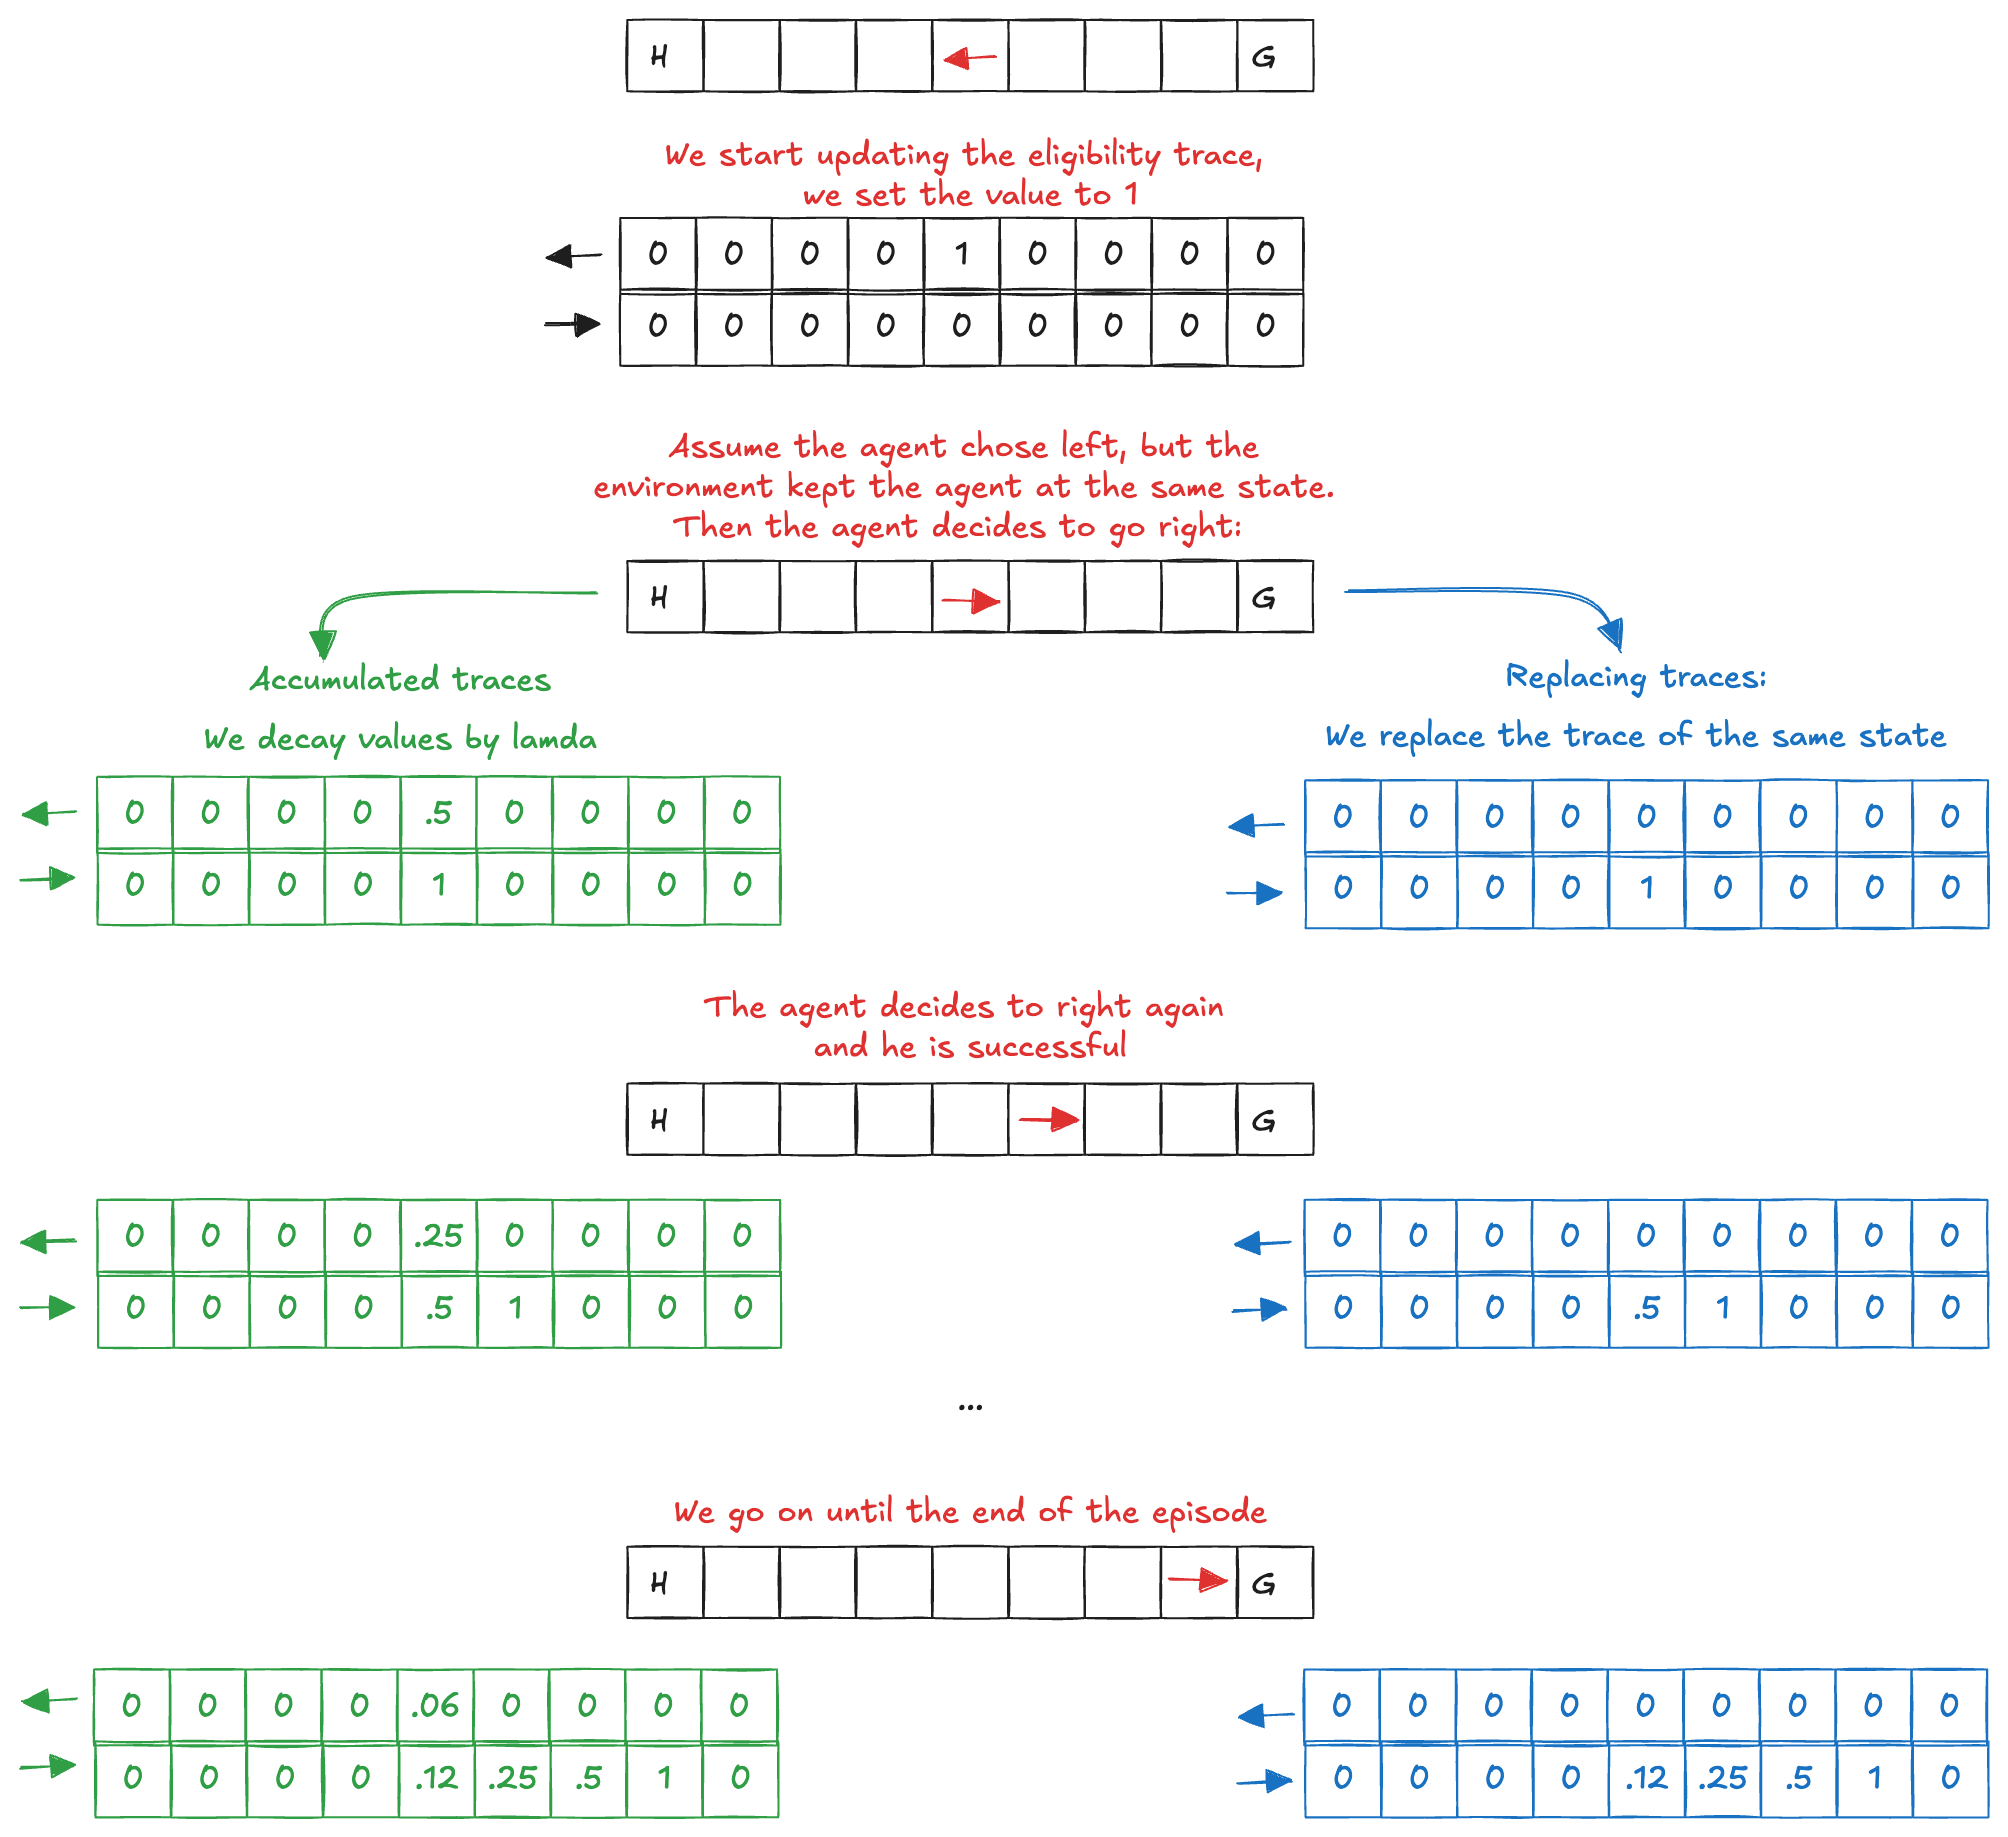

Accumulating traces can "exaggerate" when confronted with frequency, while replacing traces moderate the blame assigned to frequent events. This moderation can help the more recent, but rare events surface and be taken into account. We can implement this variation of SARSA in Python:

In [ ]:
def sarsa_lambda(env, gamma=0.99, 
                 init_alpha=0.5, min_alpha=0.01, 
                 init_epsilon=1.0, min_epsilon=0.1, 
                 lambda_=0.5, replacing_traces=True,
                 decay_episodes=1000, n_episodes=3000):
    
    # calculate the learning rate schedule for all episodes    
    alphas = decay_schedule(init_alpha, min_alpha, decay_episodes, n_episodes);

    # calculate epsilon for all episodes   
    epsilons = decay_schedule(init_epsilon, min_epsilon, decay_episodes, n_episodes);

    # initialize the current estimate of the action-value function
    q = np.zeros((env.observation_space, env.action_space), dtype=float);

    # eligibility traces
    E = np.zeros((env.observation_space, env.action_space), dtype=float);

    # create a list to save copies of v for offline analysis
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float);

    # the episode loop
    for e in range(n_episodes):
      
        # every new episode, set the eligibility of every state to zero
        E.fill(0);

        # we start episode by resetting the environment and the done flag
        state, done = env.reset(), False;

        # select the action (perhaps exploratory) for the initial state
        action = select_action(state, q, epsilons[e]);
        
        # repeat until we hit a terminal state
        while not done:
            
            # step the environment using that action
            next_state, reward, terminated, truncated, info = env.step(action);
            if(terminated or truncated):
                done = True;
            
            # obtain the action for the next step
            next_action = select_action(next_state, q, epsilons[e]);

            # calculate the target using that next state-action pair
            sarsa_lambda_target = reward + gamma * q[next_state][next_action];
            
            # calculate the error  
            sarsa_lambda_error = sarsa_lambda_target - q[state][action];
            
            # increment the state-action pair trace, 
            # and clip it to 1 if it’s a replacing trace
            if replacing_traces: 
                E[state].fill(0);
            E[state][action] = E[state][action] + 1;
            if replacing_traces: 
                E.clip(0, 1, out=E);
            
            # apply the error to all eligible state-action pairs at once
            # even though we're using the entire q-table, E will be mostly 0, 
            # and greater than zero for eligible pairs
            q = q + alphas[e] * sarsa_lambda_error * E;
            
            # decay the eligibility matrix
            E = lambda_ * E;
            
            # update state and action for the next step
            state, action = next_state, next_action;
        
        # extract the state-value function   
        v = np.max(q, axis=1);

        # and the greedy policy
        def pi(s):
            return np.argmax(q[s]);

        # save values for post analysis   
        v_track[e] = v;
    
    return q, v, pi, v_track;

We can apply the algorithm to the same SWS environment:

In [29]:
q_sarsa_lambda, v_sarsa_lambda, pi_sarsa_lambda, v_track_sarsa_lambda = sarsa_lambda(slippery_walk);

In [30]:
print(v_sarsa_lambda);

[0.         0.49629043 0.713757   0.81630604 0.88155212 0.9197797
 0.94863288 0.9778924  0.        ]


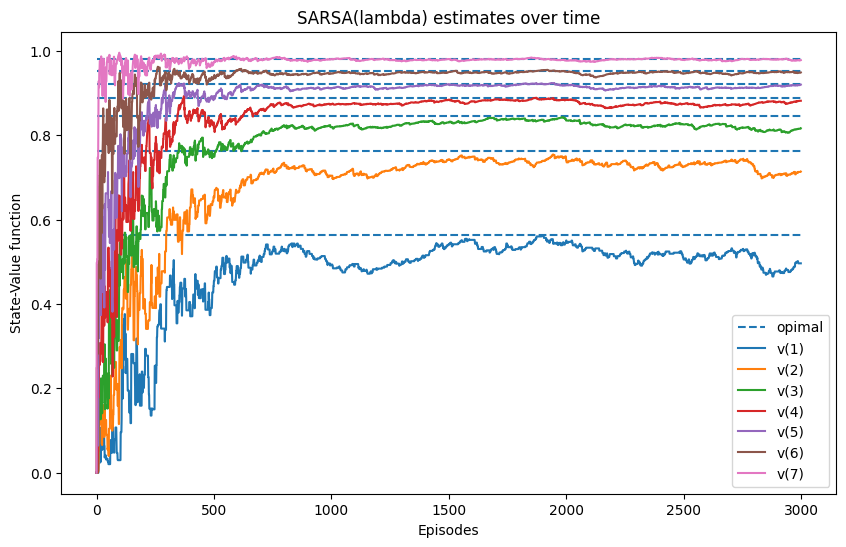

In [31]:
plt.figure(figsize=(10,6));
plt.hlines(optimal_v[1:8], 0, 3000, linestyle='--');
plt.plot(v_track_sarsa_lambda[:,1:8]);
plt.title('SARSA(lambda) estimates over time');
plt.ylabel('State-Value function');
plt.xlabel('Episodes');
plt.legend(legends);
plt.show();

By updating past state-action pairs, Sarsa(almbda) learns faster in environments where rewards are delayed. It is better at distributing the reward credit over multiple past actions, making it effective in tasks with longer time dependencies. However it requires maintaining eligibility traces and tuning the lambda parameter, making it more computationally demanding than regular Sarsa. Moreover, the choice of lambda can significantly affect performance, and improper tuning might degrade learning performance.

### Using multi-step estimates and decoupling behaviour from learning: Q(lambda)

We can extend also the Q-learning in order to use the lambda-return for evaluation. We need to replace the target (that uses the max over the action in the next state) with a lambda-return. Moreover, since Q-learning is an off-policy method, we must use the eligibility trace with care. We’re learning about the greedy policy, but following an exploratory policy. So, if an action we’ll take on the next state is a greedy action (so if the exploratory policy follows the same path of the greedy policy), then we decay the eligibility matrix as usual. Otherwise, we must reset the eligibility matrix to zero because we’ll no longer be learning about the greedy policy. We implement this idea in Python:

In [32]:
def q_lambda(env, gamma=0.99, 
             init_alpha=0.5, min_alpha=0.01, 
             init_epsilon=1.0, min_epsilon=0.1, 
             lambda_=0.5, replacing_traces=True,
             decay_episodes=1000, n_episodes=3000):
    
    # calculate the learning rate schedule for all episodes    
    alphas = decay_schedule(init_alpha, min_alpha, decay_episodes, n_episodes);

    # calculate epsilon for all episodes   
    epsilons = decay_schedule(init_epsilon, min_epsilon, decay_episodes, n_episodes);

    # initialize the current estimate of the action-value function
    q = np.zeros((env.observation_space, env.action_space), dtype=float);
        
    # eligibility traces
    E = np.zeros((env.observation_space, env.action_space), dtype=float);

    # create a list to save copies of v for offline analysis
    v_track = np.zeros((n_episodes, env.observation_space), dtype=float);
    
    # the episode loop 
    for e in range(n_episodes):
        
        # every new episode, set the eligibility of every state to zero
        E.fill(0);
        
        # we start episode by resetting the environment and the done flag
        state, done = env.reset(), False;
        
        # notice: we are preselecting the action as in SARSA, (we didn’t do that in Q-learning) 
        # this is because we need to check whether our next action is greedy for deciding
        # to decay the eligibility trace
        action = select_action(state, q, epsilons[e])
        
        # repeat until we hit a terminal state
        while not done:
            
            # step the environment using that action
            next_state, reward, terminated, truncated, info = env.step(action);
            if(terminated or truncated):
                done = True;
            
            # select the next_action SARSA-style
            next_action = select_action(next_state, q, epsilons[e])
            
            # use it to verify that the action on the next step 
            # will still come from the greedy policy
            next_action_is_greedy = q[next_state][next_action] == q[next_state].max()

            # still calculate the target as in regular Q-learning, using the max
            q_lambda_learning_target = reward + gamma * q[next_state].max();
            
            # and use the target to calculate TD error
            q_lambda_learning_error = q_lambda_learning_target - q[state][action];
            
            # increment the state-action pair trace, 
            # and clip it to 1 if it’s a replacing trace
            if replacing_traces: 
                E[state].fill(0);
            E[state][action] = E[state][action] + 1
            if replacing_traces: 
                E.clip(0, 1, out=E);
            
            # as before, we multiply the entire eligibility trace matrix 
            # by the error and the learning rate corresponding to episode e, 
            q = q + alphas[e] * q_lambda_learning_error * E
            
            # if the action we’ll take on the next state (which we already selected) is a greedy action, 
            # then we decay the eligibility matrix as usual, otherwise, we must reset 
            # the eligibility matrix to zero because we’ll no longer be learning about the greedy policy
            if next_action_is_greedy:
                E =  lambda_ * E;
            else:
                E.fill(0);
            
            # update state and action for the next step
            state, action = next_state, next_action

        # extract the state-value function   
        v = np.max(q, axis=1);

        # and the greedy policy
        def pi(s):
            return np.argmax(q[s]);
        
        # save values for post analysis  
        v_track[e] = v;

    return q, v, pi, v_track;

We can apply the algorithm to the same SWS environment:

In [33]:
q_ql_lambda, v_ql_lambda, pi_ql_lambda, v_track_ql_lambda = q_lambda(slippery_walk);

In [34]:
print(v_ql_lambda)

[0.         0.57036203 0.76187365 0.84324413 0.89254433 0.92592254
 0.9528339  0.98104672 0.        ]


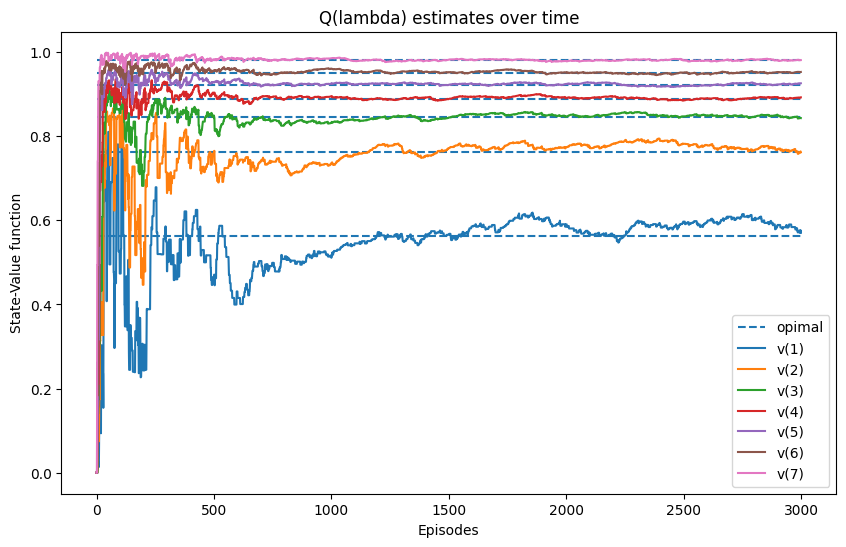

In [35]:
plt.figure(figsize=(10,6));
plt.hlines(optimal_v[1:8], 0, 3000, linestyle='--');
plt.plot(v_track_ql_lambda[:,1:8]);
plt.title('Q(lambda) estimates over time');
plt.ylabel('State-Value function');
plt.xlabel('Episodes');
plt.legend(legends);
plt.show();

Also in this case, by using eligibility traces to update not only the current state-action pair, but also past state-action pairs that contributed to the current reward, Q(lambda) can learn faster by assigning credit to prior states. However, the same observations on complexity and the need for tuning made for Sarsa(lambda) apply to Q(lambda) as well.

## Comparison

In order to compare the different algorithms, we can consider the state-value function estimation error as the mean absolute error across all estimates from their respective optimal. Take a look at how quickly Q-learning drops near zero, but also how double Q-learning gets to the lowest error first: 

In [36]:
def moving_average(a, n=100) :
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

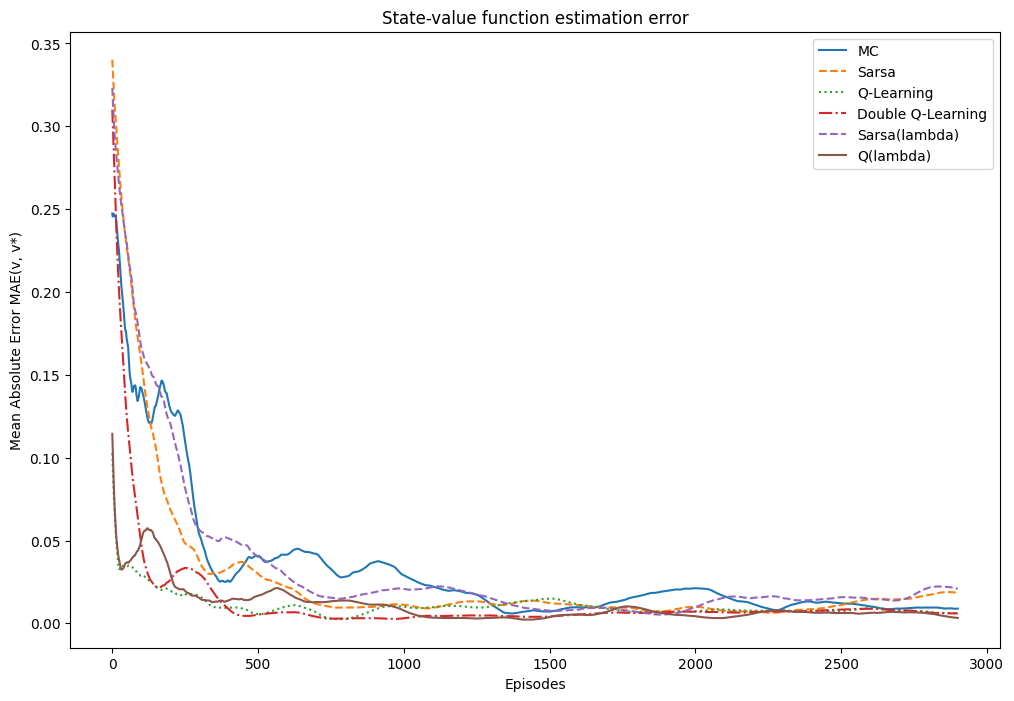

In [37]:
plt.figure(figsize=(12,8))
plt.plot(moving_average(np.mean(np.abs(v_track_mc - optimal_v), axis=1)), '-', label='MC');
plt.plot(moving_average(np.mean(np.abs(v_track_sarsa - optimal_v), axis=1)), '--', label='Sarsa');
plt.plot(moving_average(np.mean(np.abs(v_track_ql - optimal_v), axis=1)), ':', label='Q-Learning');
plt.plot(moving_average(np.mean(np.abs(v_track_dql - optimal_v), axis=1)), '-.', label='Double Q-Learning');
plt.plot(moving_average(np.mean(np.abs(v_track_sarsa_lambda - optimal_v), axis=1)), '--', label='Sarsa(lambda)');
plt.plot(moving_average(np.mean(np.abs(v_track_ql_lambda - optimal_v), axis=1)), '-', label='Q(lambda)');
plt.legend(loc=1, ncol=1);
plt.title('State-value function estimation error');
plt.xlabel('Episodes');
plt.ylabel('Mean Absolute Error MAE(v, v*)');
plt.show();

In the end, Monte Carlo is simple but slow and limited to episodic tasks; Sarsa is more conservative, focusing on actions based on the current policy, and works well when stability is needed; Q-learning aggressively learns the optimal policy but is prone to overestimation. Double Q-learning is a better alternative when stability is a concern, as it mitigates overestimation. Sarsa(lambda) and Q(lambda) provide a middle ground between learning speed and robustness by using eligibility traces, with Q(lmbda) being faster due to its off-policy nature. The choice of algorithm often depends on the specific environment and the need for stability, exploration, and learning speed.